# E-Commerce Fraud Detection Project
#### Description: The project is aimed to build an intelligent machine learning based system to help e-commerce merchants predict and detect fraudulent transactions and activities.
#### Author: Ireoluwawolemi Jeremiah Akindipe (Data Scientist)

# Libraries and Data

In [24]:
import os
import json
import joblib
from pathlib import Path
from datetime import datetime, timezone

import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (
    auc,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    RocCurveDisplay,
    precision_recall_curve,
    average_precision_score,
    precision_score,
    recall_score,
    fbeta_score,
    make_scorer,
)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

from xgboost import XGBClassifier


In [25]:
PROJECT_ROOT = Path(os.getcwd()).parent
DATA_DIR = PROJECT_ROOT / "data" / "raw"
DATASET_PATH = DATA_DIR / "ecommerce_fraud_detection.csv"

data = pd.read_csv(DATASET_PATH)
df = pd.DataFrame(data)

# ---------------- Data Exploration ----------------
print("Missing Values:\n", df.isnull().sum())
print("\nData Types:\n", df.dtypes)
print("\nData Shape: Rows: {}, Columns: {}".format(df.shape[0], df.shape[1]))
print("\nData Summary (Description):")
display(df.describe(include='all'))
print("\nData Sample:")
display(df.head())

Missing Values:
 Transaction_ID               0
Transaction_Date             0
Transaction_Amount           0
Order_Quantity               0
Payment_Method               0
Device_Type                  0
Browser                      0
Operating_System             0
Product_Category             0
Customer_Region              0
Customer_Age                 0
Customer_Tenure_Months       0
Account_Age_Days             0
Customer_Order_Count         0
IP_Risk_Score                0
Velocity_Score               0
Merchant_Risk_Score          0
Previous_Chargebacks         0
Transactions_Last_24H        0
Transactions_Last_7D         0
Failed_Payment_Attempts      0
Login_Anomalies              0
Shipping_Billing_Mismatch    0
High_Risk_Country            0
New_Device                   0
VPN_Proxy_Used               0
Discount_Percentage          0
Fraud_Flag                   0
Fraud_Status                 0
Transaction_Hour             0
Day_of_Week                  0
Is_Weekend            

,Transaction_ID,Transaction_Date,Transaction_Amount,Order_Quantity,Payment_Method,Device_Type,Browser,Operating_System,Product_Category,Customer_Region,Customer_Age,Customer_Tenure_Months,Account_Age_Days,Customer_Order_Count,IP_Risk_Score,Velocity_Score,Merchant_Risk_Score,Previous_Chargebacks,Transactions_Last_24H,Transactions_Last_7D,Failed_Payment_Attempts,Login_Anomalies,Shipping_Billing_Mismatch,High_Risk_Country,New_Device,VPN_Proxy_Used,Discount_Percentage,Fraud_Flag,Fraud_Status,Transaction_Hour,Day_of_Week,Is_Weekend,Amount_per_Item
count,15000,15000,15000.000000,15000.000000,15000,15000,15000,15000,15000,15000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000,15000.000000,15000.000000,15000.000000,15000.000000
unique,15000,15000,NaN,NaN,5,3,5,5,8,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,NaN,NaN,NaN,NaN
top,TXN00000001,2022-01-01 00:00:00,NaN,NaN,Credit Card,Mobile,Chrome,macOS,Sports,North,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Legitimate,NaN,NaN,NaN,NaN
freq,1,1,NaN,NaN,3087,8711,7755,3034,1910,3045,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11262,NaN,NaN,NaN,NaN
mean,NaN,NaN,73.977122,3.196333,NaN,NaN,NaN,NaN,NaN,NaN,46.356267,60.698600,1250.528067,15.030267,24.889376,26.707776,35.162216,0.118667,2.411000,7.500133,0.547267,0.349867,0.108267,0.056800,0.218667,0.098867,14.959667,0.249200,NaN,11.498467,3.000067,0.286600,29.558381
std,NaN,NaN,101.982605,1.475556,NaN,NaN,NaN,NaN,NaN,NaN,16.683470,34.804415,717.993671,3.743601,14.384036,18.007435,15.752967,0.344179,1.544961,2.743836,0.738965,0.593422,0.310727,0.231468,0.413356,0.298493,10.054358,0.432564,NaN,6.922417,2.001683,0.452188,45.765554
min,NaN,NaN,0.900000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,18.000000,1.000000,15.000000,2.000000,0.220000,0.170000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,0.000000,0.000000,0.000000,0.220000
25%,NaN,NaN,22.557500,2.000000,NaN,NaN,NaN,NaN,NaN,NaN,32.000000,30.000000,628.000000,12.000000,13.820000,13.367500,24.350000,0.000000,1.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,0.000000,NaN,5.000000,1.000000,0.000000,7.290000
50%,NaN,NaN,45.070000,3.000000,NaN,NaN,NaN,NaN,NaN,NaN,46.000000,61.000000,1254.000000,15.000000,22.820000,22.780000,35.090000,0.000000,2.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,15.000000,0.000000,NaN,11.000000,3.000000,0.000000,15.620000
75%,NaN,NaN,88.972500,4.000000,NaN,NaN,NaN,NaN,NaN,NaN,61.000000,91.000000,1868.000000,17.000000,33.880000,35.762500,45.832500,0.000000,3.000000,9.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,25.000000,0.000000,NaN,17.000000,5.000000,1.000000,33.745000



Data Sample:


,Transaction_ID,Transaction_Date,Transaction_Amount,Order_Quantity,Payment_Method,Device_Type,Browser,Operating_System,Product_Category,Customer_Region,Customer_Age,Customer_Tenure_Months,Account_Age_Days,Customer_Order_Count,IP_Risk_Score,Velocity_Score,Merchant_Risk_Score,Previous_Chargebacks,Transactions_Last_24H,Transactions_Last_7D,Failed_Payment_Attempts,Login_Anomalies,Shipping_Billing_Mismatch,High_Risk_Country,New_Device,VPN_Proxy_Used,Discount_Percentage,Fraud_Flag,Fraud_Status,Transaction_Hour,Day_of_Week,Is_Weekend,Amount_per_Item
0,TXN00000001,2022-01-01 00:00:00,9.34,1,Credit Card,Mobile,Chrome,Linux,Home & Kitchen,Central,24,24,1825,8,15.89,44.70,44.09,0,4,12,0,0,0,0,0,0,10,0,Legitimate,0,5,1,9.34
1,TXN00000002,2022-01-01 02:20:10,6.66,4,Debit Card,Desktop,Chrome,iOS,Sports,Central,71,119,669,14,53.33,2.29,16.64,0,1,6,0,0,0,0,0,0,25,0,Legitimate,2,5,1,1.66
2,TXN00000003,2022-01-01 04:40:20,68.97,3,Bank Transfer,Mobile,Chrome,macOS,Home & Kitchen,Central,47,66,1781,15,28.38,32.59,47.77,0,6,7,0,0,0,0,0,0,10,0,Legitimate,4,5,1,22.99
3,TXN00000004,2022-01-01 07:00:30,23.87,1,Digital Wallet,Mobile,Chrome,Windows,Electronics,Central,55,32,1911,19,42.83,8.36,38.91,0,5,8,2,1,0,0,0,1,5,0,Legitimate,7,5,1,23.87
4,TXN00000005,2022-01-01 09:20:40,16.89,5,Digital Wallet,Mobile,Safari,Linux,Toys,Central,23,62,1095,12,31.14,8.98,11.55,0,3,6,0,1,0,0,0,0,10,0,Legitimate,9,5,1,3.38


# Data Cleaning & Feature Engineering

In [26]:
def clean_data(df):
    # Drop Duplicates
    df = df.drop_duplicates()

    # Standardize column names
    df.columns = df.columns.str.strip().str.lower()
    return df

# Creating a new time series dataframe with the 'transaction_date' column as the index
def create_time_series_df(df):
    df['transaction_date'] = pd.to_datetime(df['transaction_date'])
    time_series_df = df.set_index('transaction_date').sort_index()

    # Add Temporal Features
    time_series_df['year'] = time_series_df.index.year
    time_series_df['month'] = time_series_df.index.month
    time_series_df['day_of_week'] = time_series_df.index.dayofweek

    # Sort the dataframe by index (transaction_date)
    time_series_df = time_series_df.sort_index()
    return time_series_df

# Clean the data
df = clean_data(df)

# Create a time series dataframe
time_series_df = create_time_series_df(df)

# define features
numerical_features = ["transaction_amount", "order_quantity", "customer_age", "customer_tenure_months", "account_age_days", "customer_order_count", "ip_risk_score", "velocity_score", "merchant_risk_score",
    "previous_chargebacks", "transactions_last_24h", "transactions_last_7d", "failed_payment_attempts", "login_anomalies", "discount_percentage", "transaction_hour", "amount_per_item", "day_of_week"]
categorical_features = ["payment_method", "device_type", "browser", "operating_system", "product_category", "customer_region"]
binary_features = ["shipping_billing_mismatch", "high_risk_country", "new_device", "vpn_proxy_used", "is_weekend"]

features = numerical_features + categorical_features + binary_features



print("\nCleaned Data Sample:")
display(df.head())

print("\nTime Series Data Sample:")
display(time_series_df.head())


Cleaned Data Sample:


,transaction_id,transaction_date,transaction_amount,order_quantity,payment_method,device_type,browser,operating_system,product_category,customer_region,customer_age,customer_tenure_months,account_age_days,customer_order_count,ip_risk_score,velocity_score,merchant_risk_score,previous_chargebacks,transactions_last_24h,transactions_last_7d,failed_payment_attempts,login_anomalies,shipping_billing_mismatch,high_risk_country,new_device,vpn_proxy_used,discount_percentage,fraud_flag,fraud_status,transaction_hour,day_of_week,is_weekend,amount_per_item
0,TXN00000001,2022-01-01 00:00:00,9.34,1,Credit Card,Mobile,Chrome,Linux,Home & Kitchen,Central,24,24,1825,8,15.89,44.70,44.09,0,4,12,0,0,0,0,0,0,10,0,Legitimate,0,5,1,9.34
1,TXN00000002,2022-01-01 02:20:10,6.66,4,Debit Card,Desktop,Chrome,iOS,Sports,Central,71,119,669,14,53.33,2.29,16.64,0,1,6,0,0,0,0,0,0,25,0,Legitimate,2,5,1,1.66
2,TXN00000003,2022-01-01 04:40:20,68.97,3,Bank Transfer,Mobile,Chrome,macOS,Home & Kitchen,Central,47,66,1781,15,28.38,32.59,47.77,0,6,7,0,0,0,0,0,0,10,0,Legitimate,4,5,1,22.99
3,TXN00000004,2022-01-01 07:00:30,23.87,1,Digital Wallet,Mobile,Chrome,Windows,Electronics,Central,55,32,1911,19,42.83,8.36,38.91,0,5,8,2,1,0,0,0,1,5,0,Legitimate,7,5,1,23.87
4,TXN00000005,2022-01-01 09:20:40,16.89,5,Digital Wallet,Mobile,Safari,Linux,Toys,Central,23,62,1095,12,31.14,8.98,11.55,0,3,6,0,1,0,0,0,0,10,0,Legitimate,9,5,1,3.38



Time Series Data Sample:


,transaction_id,transaction_amount,order_quantity,payment_method,device_type,browser,operating_system,product_category,customer_region,customer_age,customer_tenure_months,account_age_days,customer_order_count,ip_risk_score,velocity_score,merchant_risk_score,previous_chargebacks,transactions_last_24h,transactions_last_7d,failed_payment_attempts,login_anomalies,shipping_billing_mismatch,high_risk_country,new_device,vpn_proxy_used,discount_percentage,fraud_flag,fraud_status,transaction_hour,day_of_week,is_weekend,amount_per_item,year,month
transaction_date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2022-01-01 00:00:00,TXN00000001,9.34,1,Credit Card,Mobile,Chrome,Linux,Home & Kitchen,Central,24,24,1825,8,15.89,44.70,44.09,0,4,12,0,0,0,0,0,0,10,0,Legitimate,0,5,1,9.34,2022,1
2022-01-01 02:20:10,TXN00000002,6.66,4,Debit Card,Desktop,Chrome,iOS,Sports,Central,71,119,669,14,53.33,2.29,16.64,0,1,6,0,0,0,0,0,0,25,0,Legitimate,2,5,1,1.66,2022,1
2022-01-01 04:40:20,TXN00000003,68.97,3,Bank Transfer,Mobile,Chrome,macOS,Home & Kitchen,Central,47,66,1781,15,28.38,32.59,47.77,0,6,7,0,0,0,0,0,0,10,0,Legitimate,4,5,1,22.99,2022,1
2022-01-01 07:00:30,TXN00000004,23.87,1,Digital Wallet,Mobile,Chrome,Windows,Electronics,Central,55,32,1911,19,42.83,8.36,38.91,0,5,8,2,1,0,0,0,1,5,0,Legitimate,7,5,1,23.87,2022,1
2022-01-01 09:20:40,TXN00000005,16.89,5,Digital Wallet,Mobile,Safari,Linux,Toys,Central,23,62,1095,12,31.14,8.98,11.55,0,3,6,0,1,0,0,0,0,10,0,Legitimate,9,5,1,3.38,2022,1


# Exploratory Data Analysis

### Statistical Analysis

Target Variable Distribution:
fraud_status
Legitimate    11262
Fraudulent     3738
Name: count, dtype: int64

 Target Variable distribution (Percentage):
fraud_status
Legitimate    75.08
Fraudulent    24.92
Name: proportion, dtype: float64


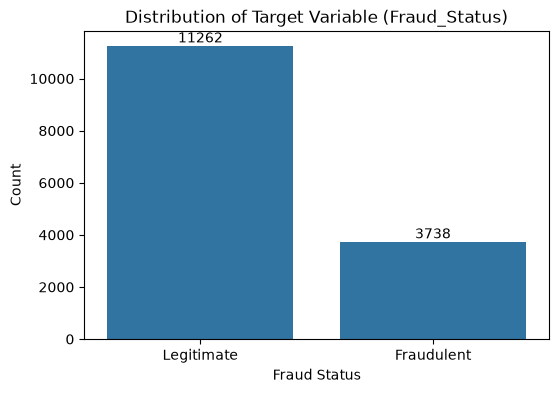

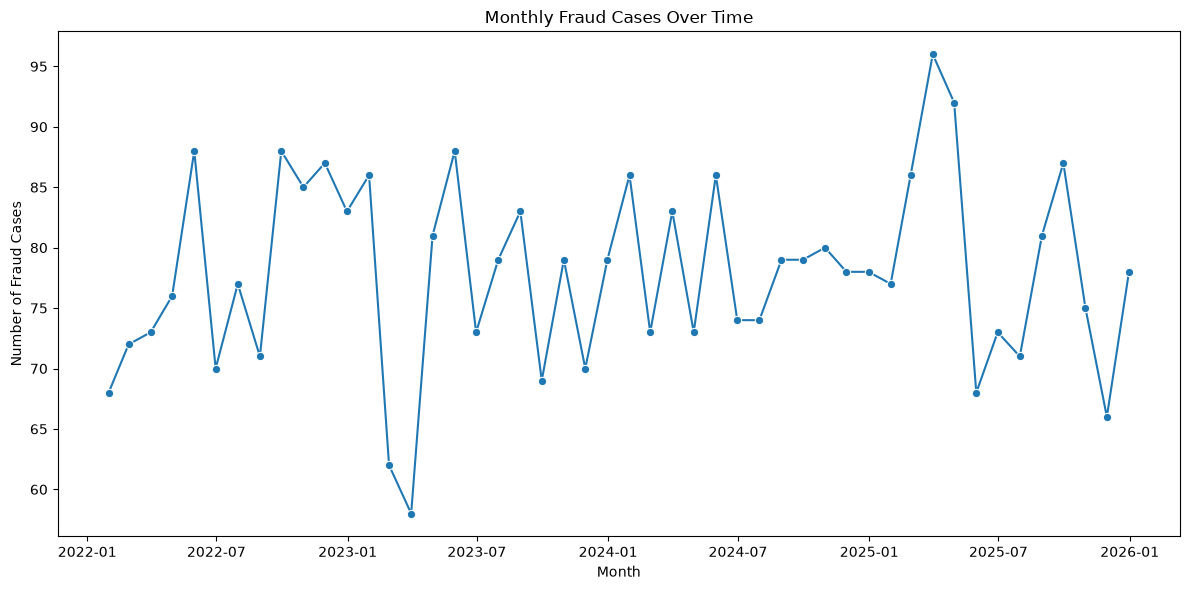

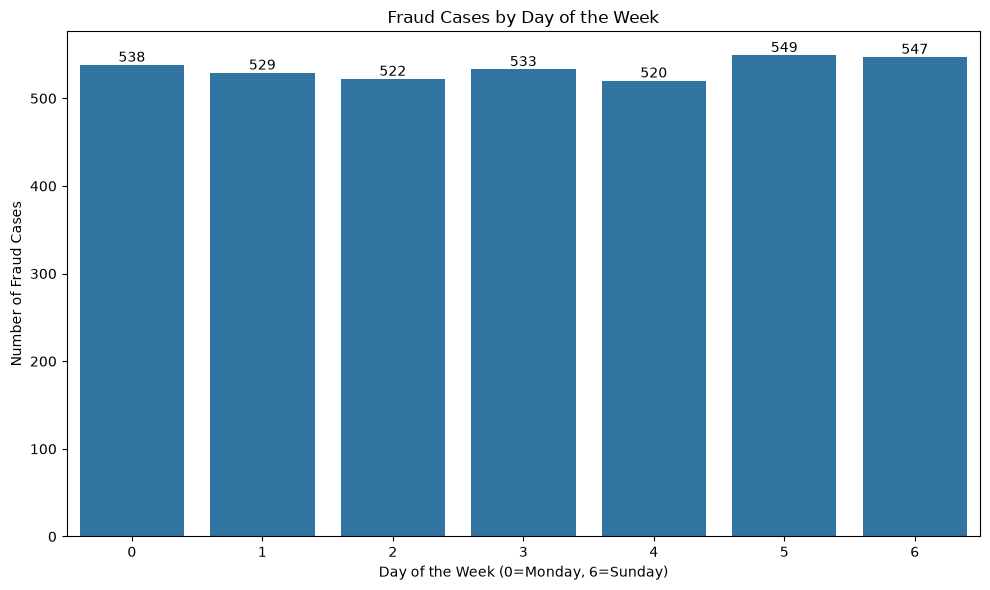


Summary Statistics for Numerical Features by Fraud Status:


fraud_status                          0        1
transaction_amount      mean      57.73   122.93
                        std       55.83   170.76
                        median    40.03    67.18
order_quantity          mean       3.17     3.27
                        std        1.47     1.49
                        median     3.00     3.00
customer_age            mean      46.43    46.12
                        std       16.69    16.67
                        median    46.00    46.00
customer_tenure_months  mean      61.07    59.58
                        std       34.81    34.76
                        median    61.00    59.00
account_age_days        mean    1291.70  1126.49
                        std      713.44   717.50
                        median  1314.00  1059.50
customer_order_count    mean      15.11    14.78
                        std        3.77     3.65
                        median    15.00    15.00
ip_risk_score           mean      23.61    28.76
                        std       13.68    15.70
                        median    21.58    27.06
velocity_score          mean      24.82    32.39
                        std       16.46    21.02
                        median    21.24    27.96
merchant_risk_score     mean      34.79    36.29
                        std       15.69    15.90
                        median    34.76    36.50
previous_chargebacks    mean       0.11     0.16
                        std        0.32     0.40
                        median     0.00     0.00
transactions_last_24h   mean       2.31     2.72
                        std        1.49     1.65
                        median     2.00     3.00
transactions_last_7d    mean       7.39     7.84
                        std        2.69     2.87
                        median     7.00     8.00
failed_payment_attempts mean       0.50     0.69
                        std        0.70     0.84
                        median     0.00     0.00
login_anomalies         mean       0.30     0.50
                        std        0.55     0.69
                        median     0.00     0.00
discount_percentage     mean      14.54    16.22
                        std       10.04    10.01
                        median    15.00    15.00
transaction_hour        mean      11.46    11.60
                        std        6.93     6.89
                        median    11.00    12.00
amount_per_item         mean      23.51    47.78
                        std       29.29    73.34
                        median    14.02    23.86
day_of_week             mean       2.99     3.02
                        std        2.00     2.01
                        median     3.00     3.00

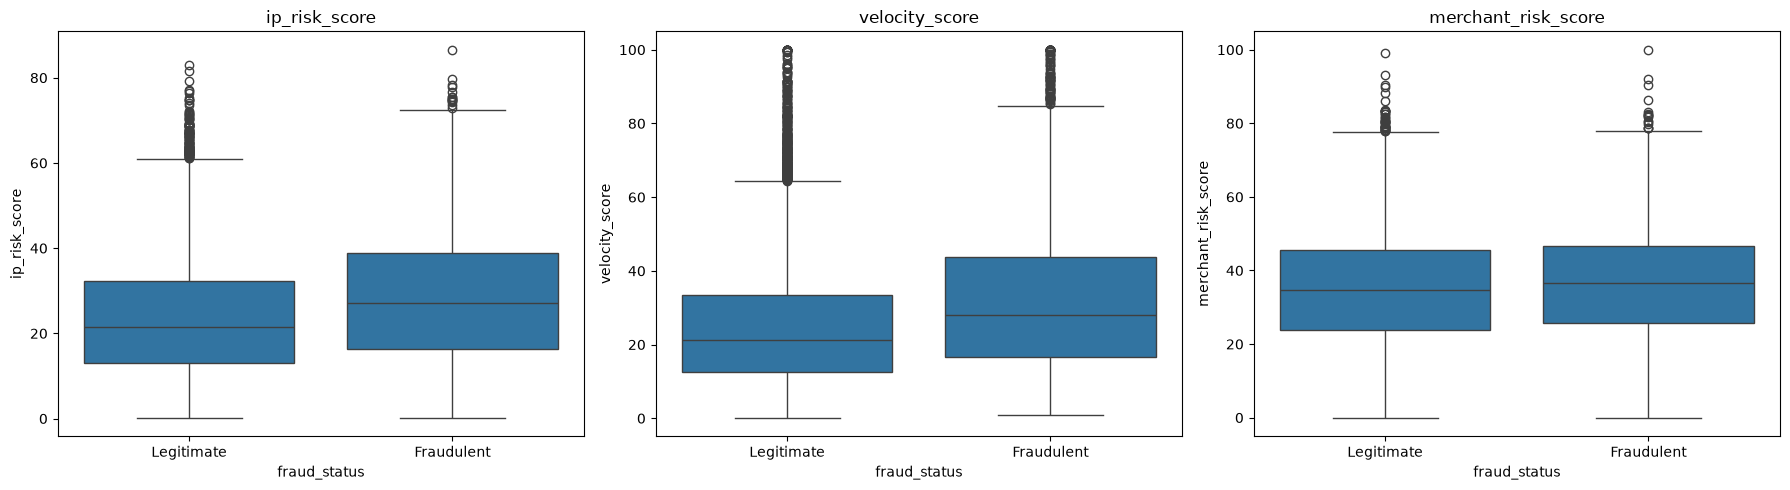

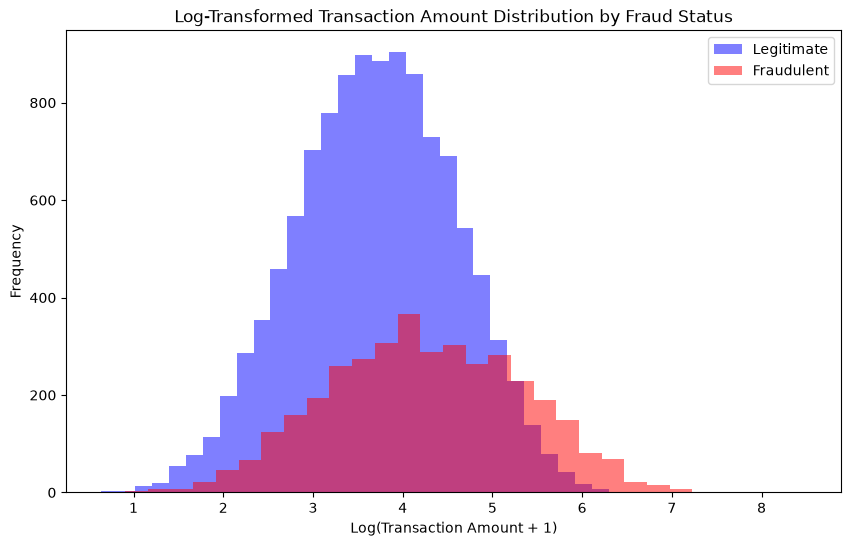


Fraud Rates by shipping_billing_mismatch:
  shipping_billing_mismatch=0: Fraud Rate=0.2293, Lift=0.92
  shipping_billing_mismatch=1: Fraud Rate=0.4132, Lift=1.66

Fraud Rates by high_risk_country:
  high_risk_country=0: Fraud Rate=0.2408, Lift=0.97
  high_risk_country=1: Fraud Rate=0.3885, Lift=1.56

Fraud Rates by new_device:
  new_device=0: Fraud Rate=0.2254, Lift=0.90
  new_device=1: Fraud Rate=0.3341, Lift=1.34

Fraud Rates by vpn_proxy_used:
  vpn_proxy_used=0: Fraud Rate=0.2319, Lift=0.93
  vpn_proxy_used=1: Fraud Rate=0.4073, Lift=1.63

Fraud Rates by is_weekend:
  is_weekend=0: Fraud Rate=0.2469, Lift=0.99
  is_weekend=1: Fraud Rate=0.2549, Lift=1.02


In [27]:
# ---------------- TARGET Variable Analysis ----------------
print("Target Variable Distribution:")
print(df['fraud_status'].value_counts())
print("\n Target Variable distribution (Percentage):")
print(df['fraud_status'].value_counts(normalize=True) * 100)
plt.figure(figsize=(6, 4))
sns.countplot(x='fraud_status', data=df)
for container in plt.gca().containers:
    plt.bar_label(container)
plt.title("Distribution of Target Variable (Fraud_Status)")
plt.xlabel("Fraud Status")
plt.ylabel("Count")
plt.show()

# ---------------- TEMPORAL Analysis ----------------
# Monthly fraud counts using fraud_flag
time_series_df['fraud_status'] = time_series_df['fraud_status'].map({'Fraudulent': 1, 'Legitimate': 0}).fillna(0).astype(int)
monthly_series = time_series_df['fraud_status'].resample('ME').sum()
monthly_df = monthly_series.reset_index().rename(columns={'transaction_date': 'month', 0: 'fraud_count'})
plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_df, x='month', y=monthly_series.values, marker='o')
plt.title("Monthly Fraud Cases Over Time")
plt.xlabel("Month")
plt.ylabel("Number of Fraud Cases")
plt.tight_layout()
plt.show()

# For day of the week (0=Monday)
dow_df = time_series_df.groupby('day_of_week')['fraud_status'].sum().reset_index().rename(columns={'fraud_status': 'fraud_count'})
plt.figure(figsize=(10, 6))
sns.barplot(data=dow_df, x='day_of_week', y='fraud_count', errorbar=None)
ax = plt.gca()
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height)}', (p.get_x() + p.get_width() / 2., height), ha='center', va='bottom')
plt.title("Fraud Cases by Day of the Week")
plt.xlabel("Day of the Week (0=Monday, 6=Sunday)")
plt.ylabel("Number of Fraud Cases")
plt.tight_layout()
plt.show()

# ----------------- NUMERIC FEATURE DISTRIBUTION -----------------
summary = time_series_df.groupby('fraud_status')[numerical_features].agg(['mean', 'std', 'median'])
print("\nSummary Statistics for Numerical Features by Fraud Status:")
display(summary.T.round(2))

# ------------- RISK SCORE ANALYSIS -------------
risk_cols = ["ip_risk_score", "velocity_score", "merchant_risk_score"]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, risk_cols):
        sns.boxplot(data=df, x="fraud_status", y=col, ax=ax)
        ax.set_title(col)
plt.tight_layout()
plt.show()
# ------------------ Amount distributions (log scale useful) ------------------
fig, ax = plt.subplots(figsize=(10, 6))
for label, color in [('Legitimate', 'blue'), ('Fraudulent', 'red')]:
    subset = df[df['fraud_status'] == label]['transaction_amount'] if 'transaction_amount' in df.columns else pd.Series([])
    if len(subset) > 0:
        ax.hist(np.log1p(subset), bins=30, alpha=0.5, label=label, color=color)
ax.set_title("Log-Transformed Transaction Amount Distribution by Fraud Status")
ax.set_xlabel("Log(Transaction Amount + 1)")
ax.set_ylabel("Frequency")
ax.legend()
plt.show()

# ---------------- BINARY FLAGS - FRAUD LIFT ----------------
overall = df['fraud_flag'].mean() if 'fraud_flag' in df.columns else df['fraud_status'].mean()
for col in binary_features:
    if col in df.columns:
        rates = df.groupby(col)['fraud_flag'].mean() if 'fraud_flag' in df.columns else df.groupby(col)['fraud_status'].mean()
        print(f"\nFraud Rates by {col}:")
        for val, rate in rates.items():
            lift = rate / overall if overall > 0 else np.nan
            print(f"  {col}={val}: Fraud Rate={rate:.4f}, Lift={lift:.2f}")


payment_method:


,mean,count
payment_method,,
Cash on Delivery,25.77%,2973
Credit Card,25.11%,3087
Digital Wallet,24.93%,3057
Bank Transfer,24.63%,3004
Debit Card,24.14%,2879


device_type:


,mean,count
device_type,,
Desktop,25.79%,5123
Tablet,25.30%,1166
Mobile,24.36%,8711


browser:


,mean,count
browser,,
Firefox,25.65%,1353
Chrome,25.09%,7755
Other,24.90%,759
Safari,24.57%,3651
Edge,24.22%,1482


operating_system:


,mean,count
operating_system,,
Linux,25.21%,2995
iOS,25.09%,3025
Windows,24.97%,2999
Android,24.97%,2947
macOS,24.36%,3034


product_category:


,mean,count
product_category,,
Sports,26.13%,1910
Beauty,25.41%,1909
Books,25.17%,1891
Electronics,25.16%,1896
Home & Kitchen,25.00%,1796
Fashion,24.44%,1886
Grocery,24.12%,1828
Toys,23.89%,1884


customer_region:


,mean,count
customer_region,,
Central,25.67%,3043
West,25.17%,3043
North,25.06%,3045
East,24.73%,2932
South,23.94%,2937


Correlation of Numerical Features with Fraud Status:
transaction_amount         0.277
amount_per_item            0.229
velocity_score             0.182
ip_risk_score              0.155
login_anomalies            0.150
transactions_last_24h      0.116
failed_payment_attempts    0.113
account_age_days          -0.100
discount_percentage        0.072
transactions_last_7d       0.071
previous_chargebacks       0.062
merchant_risk_score        0.041
customer_order_count      -0.039
order_quantity             0.028
customer_tenure_months    -0.019
transaction_hour           0.008
customer_age              -0.008
day_of_week                0.005


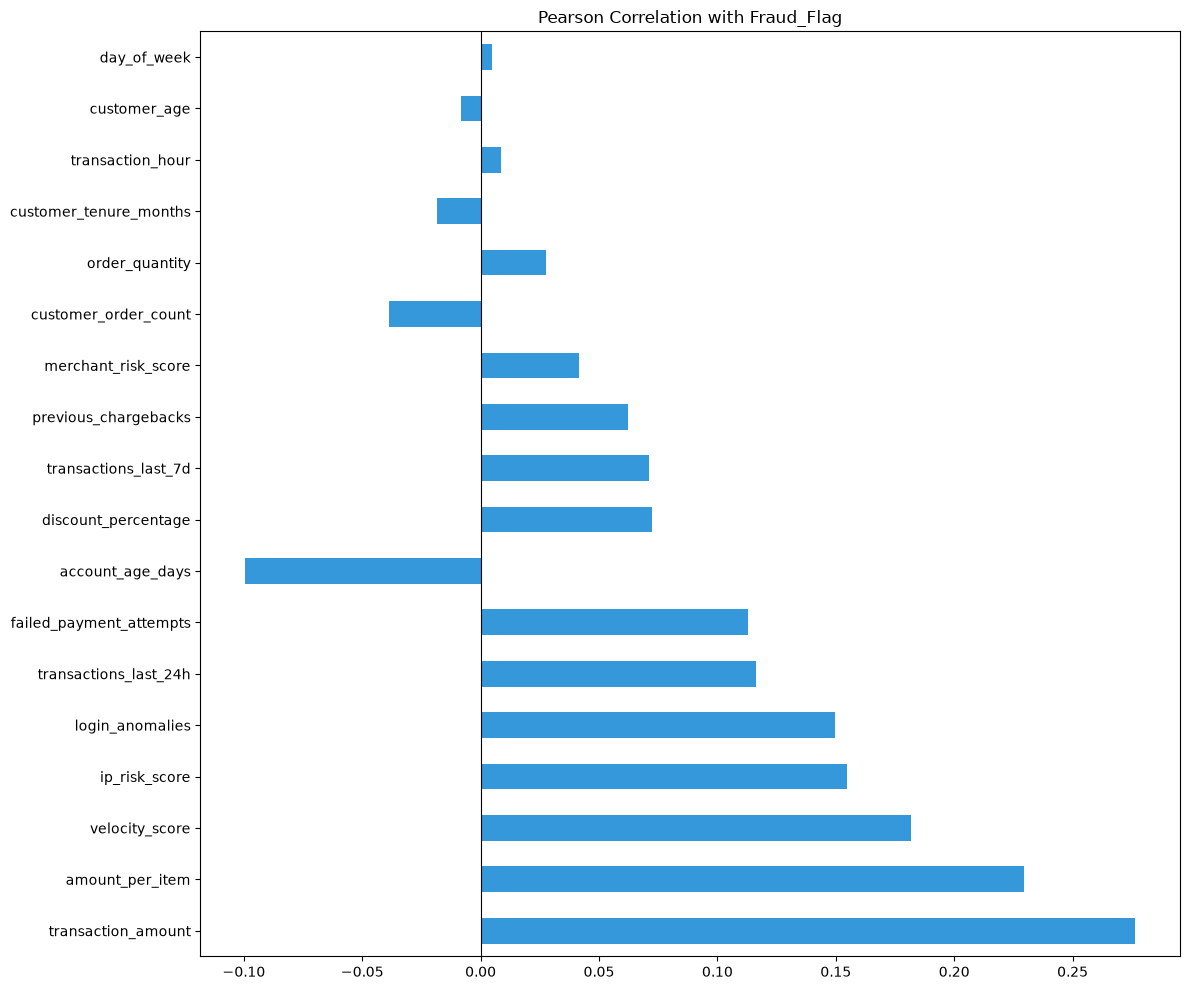

In [28]:
# ---------------- CATEGORICAL FEATURES - FRAUD RATE ----------------
for col in categorical_features:
    target_col = 'fraud_status'
    if time_series_df[target_col].dtype == object:
        time_series_df[target_col] = time_series_df[target_col].map({
            'Fraudulent': 1,
            'Legitimate': 0
        }).fillna(0).astype(int)

    rates = (
        time_series_df.groupby(col, dropna=False)[target_col]
        .agg(['mean', 'count'])
        .sort_values(by='mean', ascending=False)
    )
    rates['mean'] = rates['mean'].map(lambda x: f"{x:.2%}")
    print(f"{col}:")
    display(rates)

# ---------------- CORRELATION ANALYSIS (NUMERIC ONLY) ----------------
corr = time_series_df[numerical_features + [target_col]].corr()[target_col].drop(target_col)
# Remove duplicate feature names before building the correlation series
feature_cols = list(dict.fromkeys(numerical_features + [target_col]))
corr = time_series_df[feature_cols].corr()[target_col].drop(target_col)

# Drop any duplicate labels and sort by absolute correlation
corr = corr.loc[~corr.index.duplicated(keep='first')]
corr_sorted = corr.reindex(corr.abs().sort_values(ascending=False).index)
print("Correlation of Numerical Features with Fraud Status:")
print(corr_sorted.round(3).to_string())

# Visualization of Correlation Matrix
fig, ax = plt.subplots(figsize=(12, 10))
corr_sorted.plot(kind="barh", ax=ax, color="#3498db")
ax.set_title("Pearson Correlation with Fraud_Flag")
ax.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

### Distribution Analysis

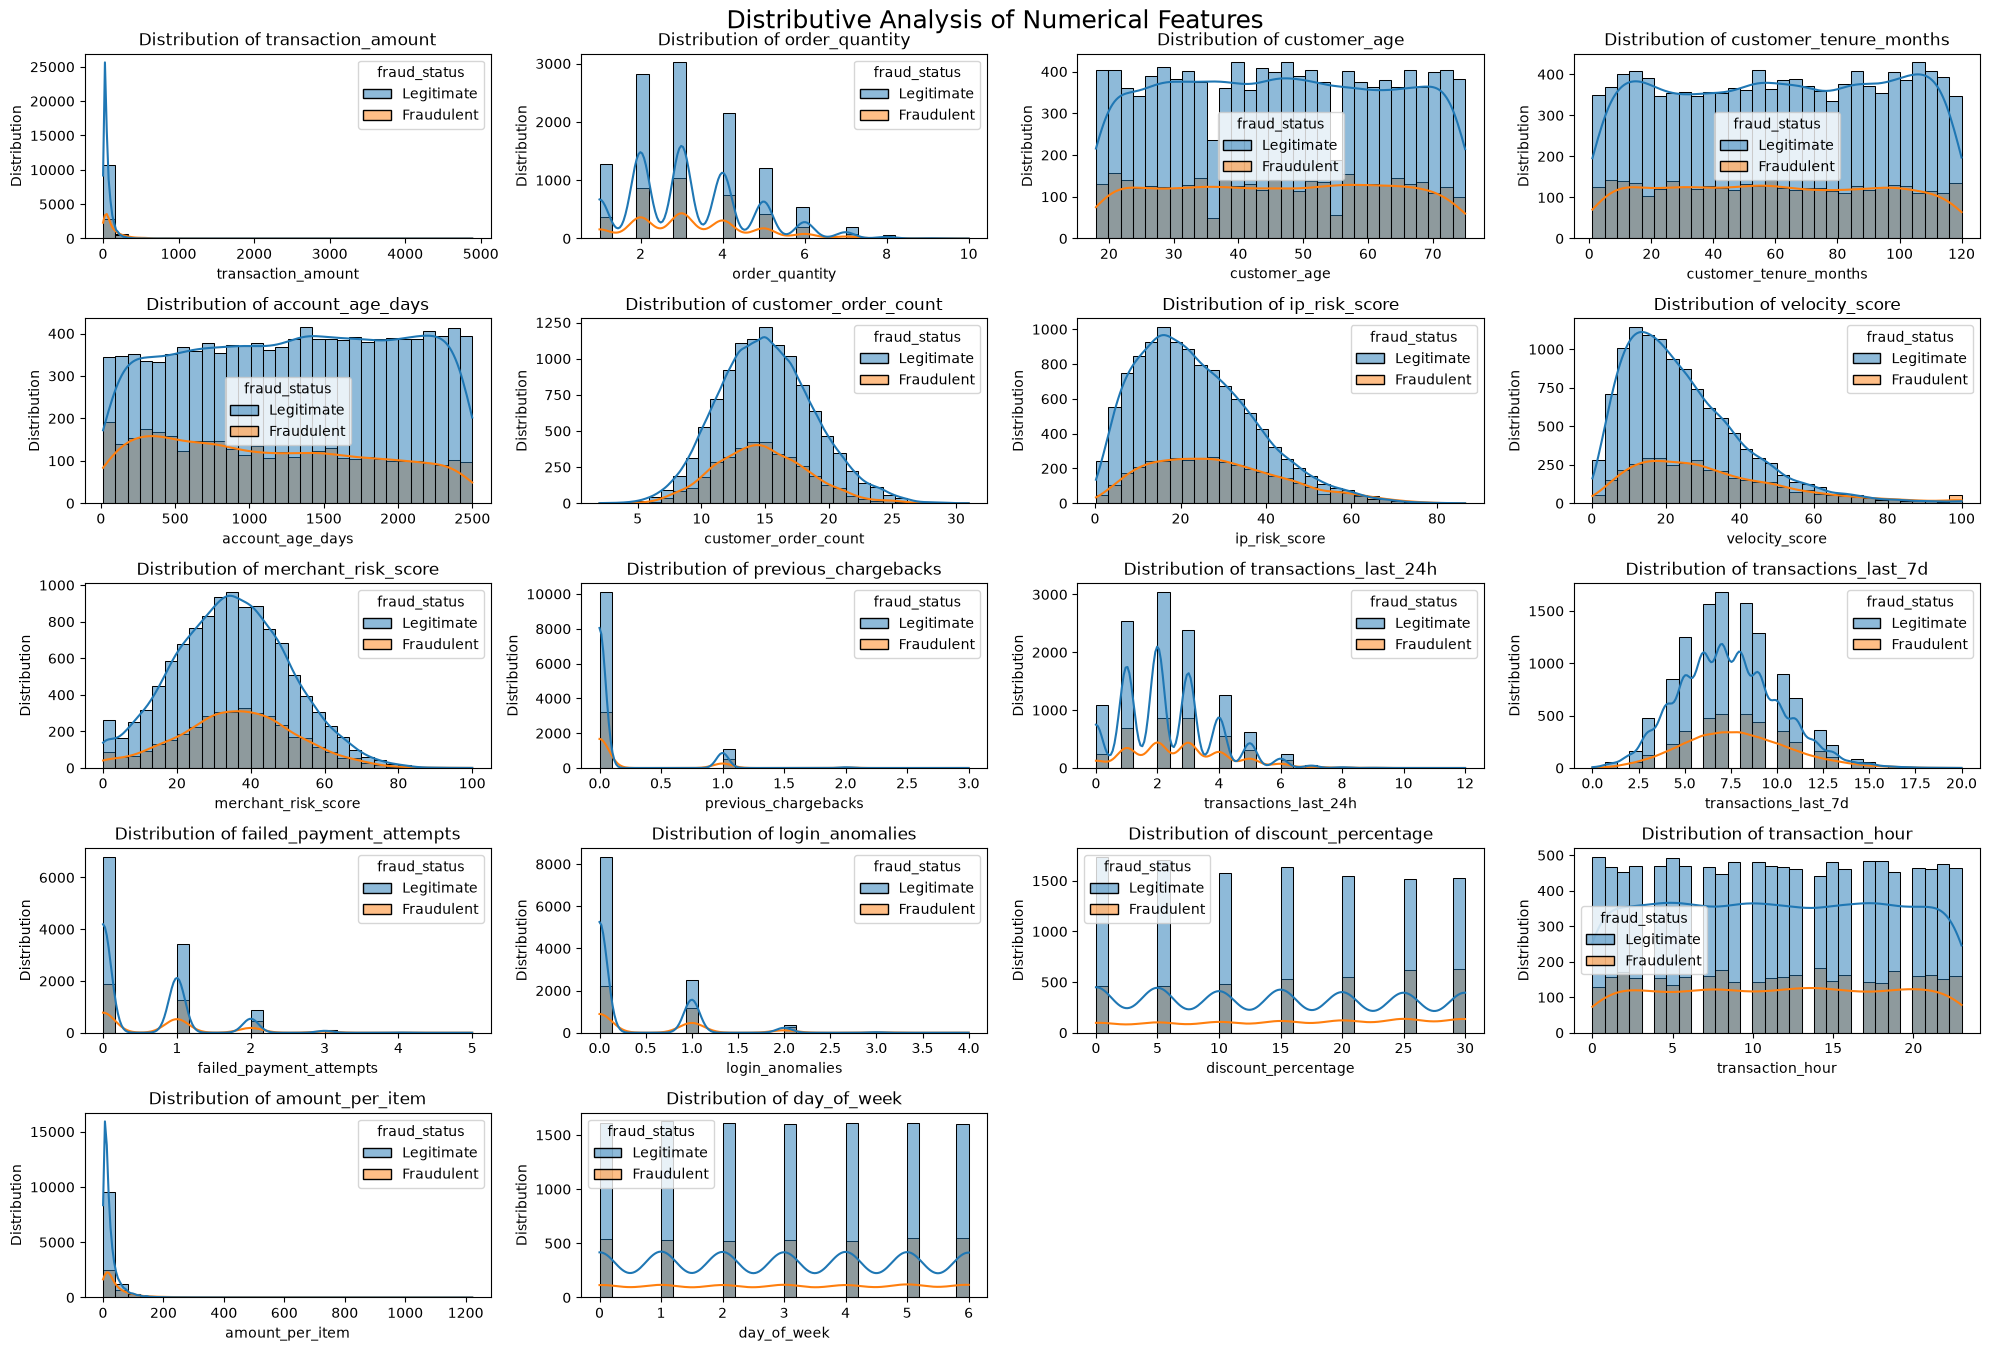

In [29]:
plt.figure(figsize=(20, 16))
for i, col in enumerate(numerical_features, 1):
    plt.subplot(6, 4, i)
    ax = sns.histplot(x=col, data=df, bins=30, hue="fraud_status", kde=True)
    plt.xlabel(col)
    plt.title(f"Distribution of {col}")
    plt.ylabel("Distribution")
plt.suptitle("Distributive Analysis of Numerical Features", fontsize=18)
plt.tight_layout()
plt.show()

## Key Findings
* Fraud rate is ~24.9% – moderately imbalanced. Prefer PR-AUC / F1 / cost-sensitive
  metrics over plain accuracy.

* Strong individual signals already present:
  - IP_Risk_Score, Velocity_Score, Merchant_Risk_Score
  - Previous_Chargebacks, Failed_Payment_Attempts, Login_Anomalies
  - Shipping_Billing_Mismatch, New_Device, VPN_Proxy_Used, High_Risk_Country

* Temporal structure exists (multi-year data). Use time-aware splits to avoid leakage.

* Transaction_Amount has a long right tail; log-transform or robust scaling may help
  linear models (trees are less sensitive).

* No missing values and unique Transaction_IDs → clean starting point.

* Business metric recommendation:
  Optimize a cost-sensitive threshold or maximize Precision-Recall AUC,
  then tune operating point according to Cost_FP ≈ 5 vs Cost_FN ≈ 100
  (adjust these numbers with real finance/ops input).

# Machine learning - Fraud Status Prediction

## Feature Engineering

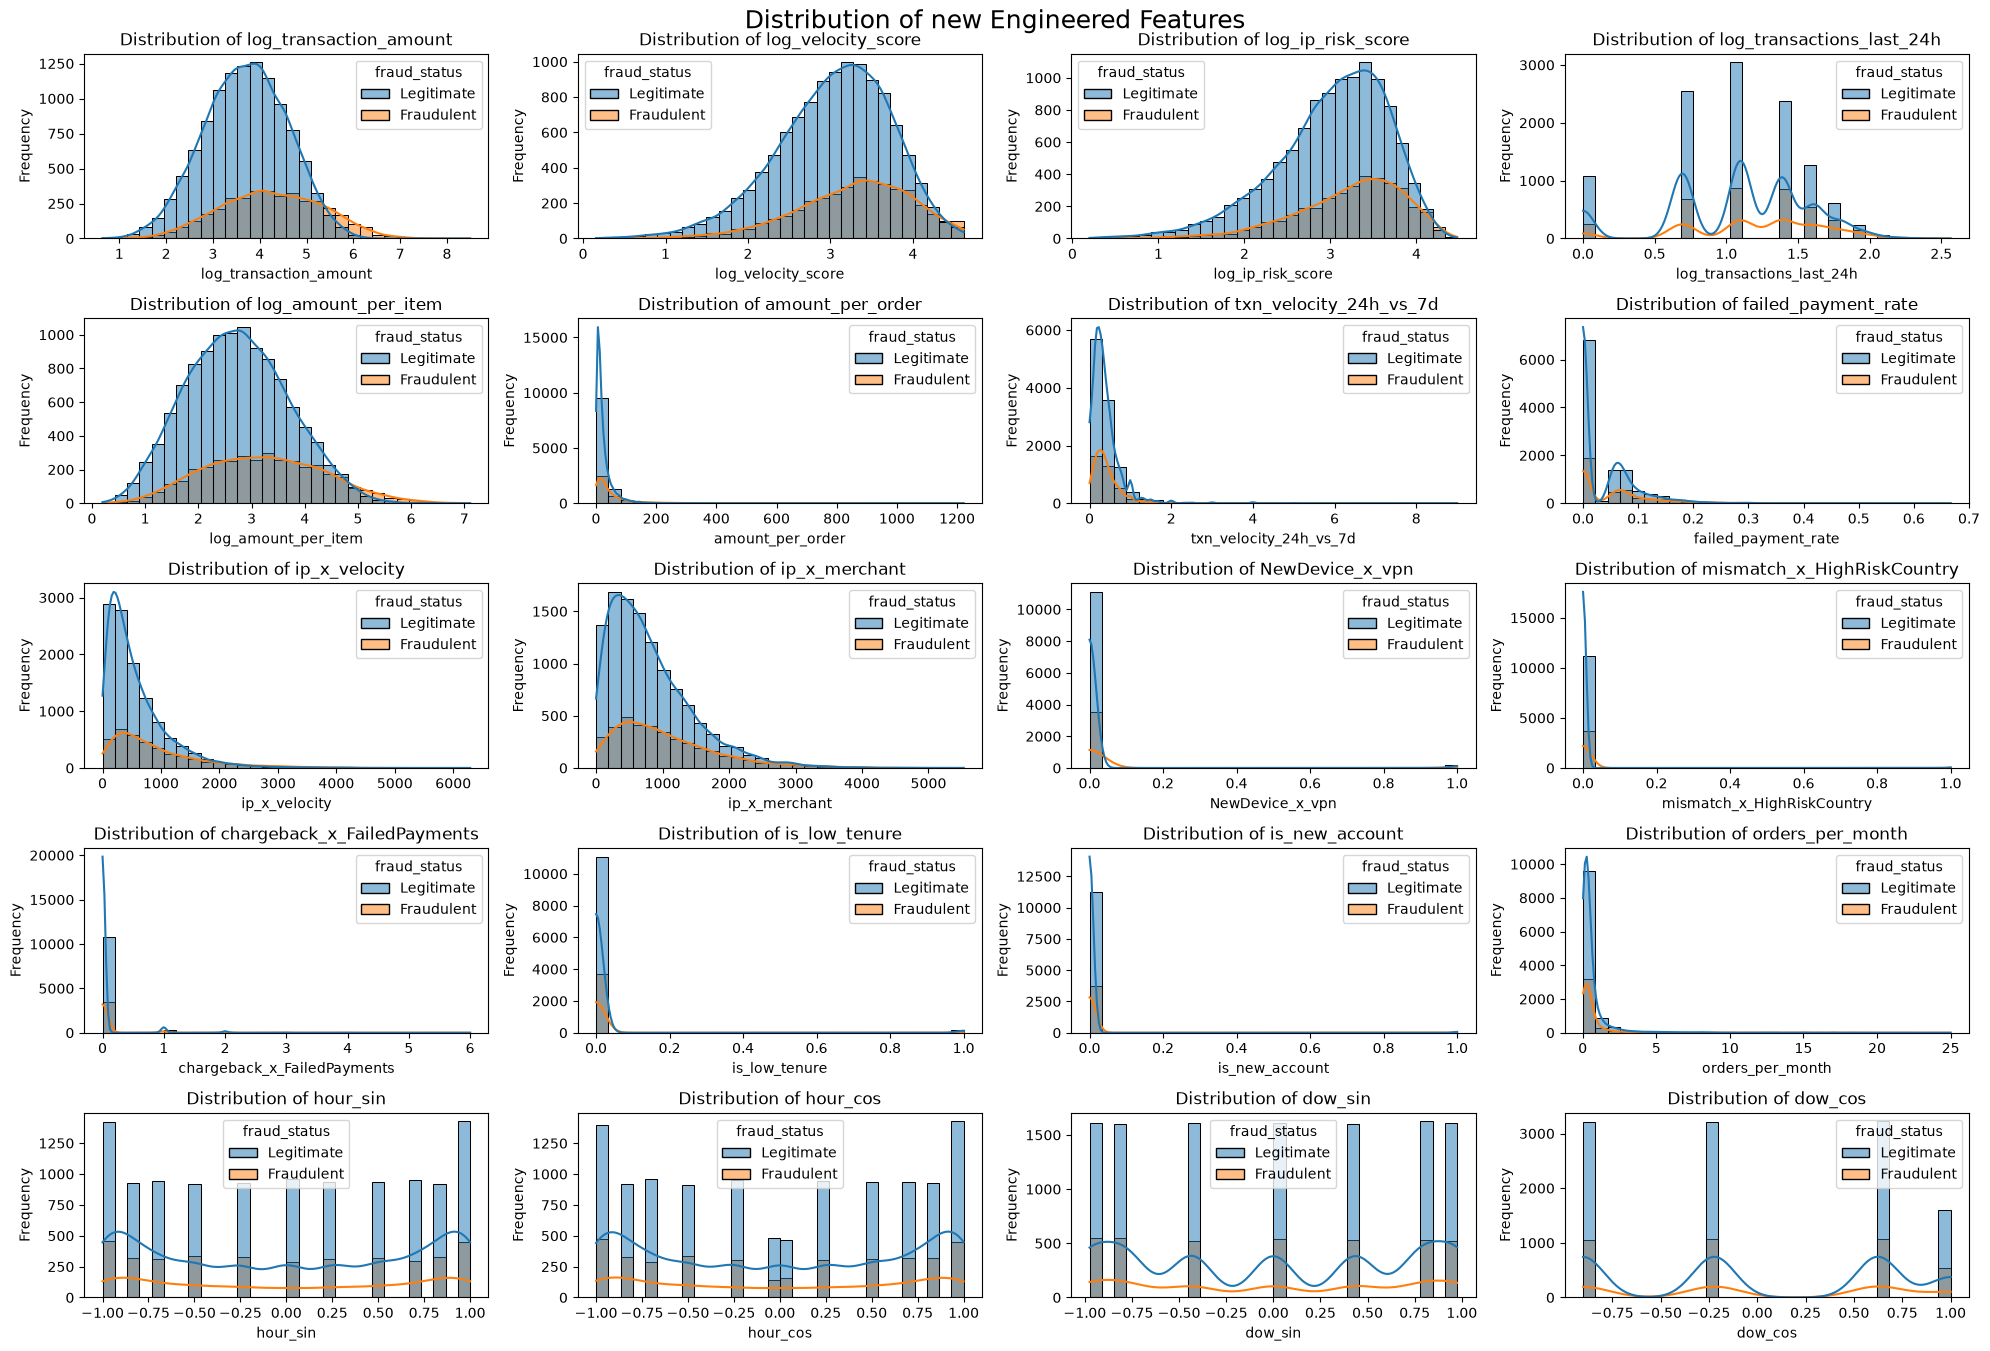

In [30]:
def feature_engineering(df):
    # Log Transform Heavy-tailed featues
    df["log_transaction_amount"] = np.log1p(df["transaction_amount"])
    df["log_velocity_score"] = np.log1p(df["velocity_score"])
    df["log_ip_risk_score"] = np.log1p(df["ip_risk_score"])
    df["log_transactions_last_24h"] = np.log1p(df["transactions_last_24h"])
    df["log_amount_per_item"] = np.log1p(df["amount_per_item"])

    # Ratios & velocity-style features
    df["amount_per_order"] = df["transaction_amount"] / df["order_quantity"].clip(lower=1)
    df["txn_velocity_24h_vs_7d"] = (
        df["transactions_last_24h"] / df["transactions_last_7d"].clip(lower=1)
    )
    df["failed_payment_rate"] = (
        df["failed_payment_attempts"] / df["customer_order_count"].clip(lower=1)
    )

    # Risk interactions (high-signal combinations from EDA)
    df["ip_x_velocity"] = df["ip_risk_score"] * df["velocity_score"]
    df["ip_x_merchant"] = df["ip_risk_score"] * df["merchant_risk_score"]
    df["NewDevice_x_vpn"] = df["new_device"] * df["vpn_proxy_used"]
    df["mismatch_x_HighRiskCountry"] = (
        df["shipping_billing_mismatch"] * df["high_risk_country"]
    )
    df["chargeback_x_FailedPayments"] = (
        df["previous_chargebacks"] * df["failed_payment_attempts"]
    )

    # Account maturity signals
    df["is_new_account"] = (df["account_age_days"] < 30).astype(int)
    df["is_low_tenure"] = (df["customer_tenure_months"] < 3).astype(int)
    df["orders_per_month"] = (
        df["customer_order_count"] / df["customer_tenure_months"].clip(lower=1)
    )

    # Time-based cyclic features (optional but useful)
    df["hour_sin"] = np.sin(2 * np.pi * df["transaction_hour"] / 24)
    df["hour_cos"] = np.cos(2 * np.pi * df["transaction_hour"] / 24)
    df["dow_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
    df["dow_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)

    return df

engineered_features = [
    "log_transaction_amount",
    "log_velocity_score",
    "log_ip_risk_score",
    "log_transactions_last_24h",
    "log_amount_per_item",
    "amount_per_order",
    "txn_velocity_24h_vs_7d",
    "failed_payment_rate",
    "ip_x_velocity",
    "ip_x_merchant",
    "NewDevice_x_vpn",
    "mismatch_x_HighRiskCountry",
    "chargeback_x_FailedPayments",
    "is_low_tenure",
    "is_new_account",
    "orders_per_month",
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos",
]

binary_features = binary_features + ["is_new_account", "is_low_tenure", "mismatch_x_HighRiskCountry", "NewDevice_x_vpn"]
numerical_features = numerical_features + ["log_transaction_amount", "log_velocity_score", "log_ip_risk_score", "log_transactions_last_24h", "log_amount_per_item", "amount_per_order",
                                           "txn_velocity_24h_vs_7d", "failed_payment_rate", "ip_x_velocity", "ip_x_merchant", "chargeback_x_FailedPayments"]

# Engineer new Features
df = feature_engineering(df)

# Visualize Engineered Features Distribution
plt.figure(figsize=(20, 16))
for i, col in enumerate(engineered_features, 1):
    plt.subplot(6, 4, i)
    ax = sns.histplot(x=col, data=df, bins=30, kde=True, hue="fraud_status")
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
plt.suptitle("Distribution of new Engineered Features", fontsize=18)
plt.tight_layout()
plt.show()

## Preprocessing

In [31]:
# Use handle_unknown="ignore" so production scoring does not fail when a new category appears.
try:
    categorical_encoder = OneHotEncoder(
        drop='first',
        handle_unknown='ignore',
        sparse_output=False,
    )
except TypeError:
    # Compatibility for older scikit-learn versions.
    categorical_encoder = OneHotEncoder(
        drop='first',
        handle_unknown='ignore',
        sparse=False,
    )

binary_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
    ])

preprocessor = ColumnTransformer(
    transformers=[
        ('scaler', StandardScaler(), numerical_features),
        ('bin', binary_transformer, binary_features),
        ('encoder', categorical_encoder, categorical_features),
    ],
    remainder='drop'
)
display(preprocessor)

# Add engineered features to features
features = features + engineered_features

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('scaler', ...), ('bin', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``featur

### Build Feature Matrix

In [32]:
# Feature Matrix 
X = df[features].copy()
y = df['fraud_status'].map({'Fraudulent': 1, 'Legitimate': 0}).dropna().astype(int)

print("Feature Matrix (X) Sample:")
display(X.head())
print("\nTarget Variable (y) Sample:")
display(y.head())

Feature Matrix (X) Sample:


,transaction_amount,order_quantity,customer_age,customer_tenure_months,account_age_days,customer_order_count,ip_risk_score,velocity_score,merchant_risk_score,previous_chargebacks,transactions_last_24h,transactions_last_7d,failed_payment_attempts,login_anomalies,discount_percentage,transaction_hour,amount_per_item,day_of_week,payment_method,device_type,browser,operating_system,product_category,customer_region,shipping_billing_mismatch,high_risk_country,new_device,vpn_proxy_used,is_weekend,log_transaction_amount,log_velocity_score,log_ip_risk_score,log_transactions_last_24h,log_amount_per_item,amount_per_order,txn_velocity_24h_vs_7d,failed_payment_rate,ip_x_velocity,ip_x_merchant,NewDevice_x_vpn,mismatch_x_HighRiskCountry,chargeback_x_FailedPayments,is_low_tenure,is_new_account,orders_per_month,hour_sin,hour_cos,dow_sin,dow_cos
0,9.34,1,24,24,1825,8,15.89,44.70,44.09,0,4,12,0,0,10,0,9.34,5,Credit Card,Mobile,Chrome,Linux,Home & Kitchen,Central,0,0,0,0,1,2.336020,3.822098,2.826722,1.609438,2.336020,9.340,0.333333,0.000000,710.2830,700.5901,0,0,0,0,0,0.333333,0.000000,1.000000,-0.974928,-0.222521
1,6.66,4,71,119,669,14,53.33,2.29,16.64,0,1,6,0,0,25,2,1.66,5,Debit Card,Desktop,Chrome,iOS,Sports,Central,0,0,0,0,1,2.036012,1.190888,3.995077,0.693147,0.978326,1.665,0.166667,0.000000,122.1257,887.4112,0,0,0,0,0,0.117647,0.500000,0.866025,-0.974928,-0.222521
2,68.97,3,47,66,1781,15,28.38,32.59,47.77,0,6,7,0,0,10,4,22.99,5,Bank Transfer,Mobile,Chrome,macOS,Home & Kitchen,Central,0,0,0,0,1,4.248067,3.514228,3.380314,1.945910,3.177637,22.990,0.857143,0.000000,924.9042,1355.7126,0,0,0,0,0,0.227273,0.866025,0.500000,-0.974928,-0.222521
3,23.87,1,55,32,1911,19,42.83,8.36,38.91,0,5,8,2,1,5,7,23.87,5,Digital Wallet,Mobile,Chrome,Windows,Electronics,Central,0,0,0,1,1,3.213662,2.236445,3.780319,1.791759,3.213662,23.870,0.625000,0.105263,358.0588,1666.5153,0,0,0,0,0,0.593750,0.965926,-0.258819,-0.974928,-0.222521
4,16.89,5,23,62,1095,12,31.14,8.98,11.55,0,3,6,0,1,10,9,3.38,5,Digital Wallet,Mobile,Safari,Linux,Toys,Central,0,0,0,0,1,2.884242,2.300583,3.470101,1.386294,1.477049,3.378,0.500000,0.000000,279.6372,359.6670,0,0,0,0,0,0.193548,0.707107,-0.707107,-0.974928,-0.222521



Target Variable (y) Sample:


0    0
1    0
2    0
3    0
4    0
Name: fraud_status, dtype: int64

### Train Test Split

In [33]:
# Train-Test Split (70% train, 15% test, 15% validation) with stratification to maintain class distribution

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)  # 0.25 x 0.8 = 0.2

print(f"Train Set Shape: , {X_train.shape, y_train.shape}, Train Set Size: , {((len(X_train) / len(df)) * 100):.2f}%")
print(f"Validation Set Shape: , {X_val.shape, y_val.shape}, Validation Set Size: , {((len(X_val) / len(df)) * 100):.2f}%")
print(f"Test Set Shape: , {X_test.shape, y_test.shape}, Test Set Size: , {((len(X_test) / len(df)) * 100):.2f}%")

Train Set Shape: , ((10500, 49), (10500,)), Train Set Size: , 70.00%
Validation Set Shape: , ((2250, 49), (2250,)), Validation Set Size: , 15.00%
Test Set Shape: , ((2250, 49), (2250,)), Test Set Size: , 15.00%


### Utils

In [34]:
# For Classification Report
def plot_classification_report(report, title="Classification Report", ax=None, target_names=["Legitimate", "Fraudulent"]):
    # Convert report dictionary directly to a DataFrame
    cr_df = pd.DataFrame(report).T
    # Rename numerical class indices ('0', '1') to target names
    rename_dict = {str(i): name for i, name in enumerate(target_names)}
    # Support numeric keys if dict keys are integers instead of strings
    rename_dict.update({i: name for i, name in enumerate(target_names)}) 
    cr_df = cr_df.rename(index=rename_dict)
    # Ensure correct metric order
    metrics = ["precision", "recall", "f1-score", "support"]
    cr_df = cr_df[metrics]
    # Handle accuracy row (accuracy only returns a single value in scikit-learn report dicts)
    if "accuracy" in cr_df.index:
        acc_value = report["accuracy"]
        cr_df.loc["accuracy"] = [acc_value, acc_value, acc_value, report.get("macro avg", {}).get("support", 0)]
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
    # Format text inside heatmap: whole numbers for support, 2 decimals for floating metrics
    annot_matrix = cr_df.copy()
    for col in annot_matrix.columns:
        if col == "support":
            annot_matrix[col] = annot_matrix[col].apply(lambda x: f"{int(x)}")
        else:
            annot_matrix[col] = annot_matrix[col].apply(lambda x: f"{x:.2f}")
    sns.heatmap(cr_df, annot=annot_matrix, fmt="", cmap="Blues", ax=ax, cbar=True)
    ax.set_title(title)
    ax.set_xlabel("Metrics")
    ax.set_ylabel("Classes / Summaries")
    return ax

# For Confusion Matrix
def plot_confusion_matrix(cm, title="Confusion Matrix", ax=None, target_names=["Legitimate", "Fraudulent"]):
    # Build a DataFrame from the confusion matrix with readable labels
    labels = [target_names[0], target_names[1]]
    cm_df = pd.DataFrame(cm, index=labels, columns=labels)
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues", ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

# For ROC-AUC Visualization
def plot_roc_auc_score(y_true, y_pred_proba, title="ROC Curve", ax=None, color="darkorange"):
    """
        Plots the ROC curve and returns the calculated ROC-AUC score.
        
        Parameters:
        - y_true: Ground truth binary labels.
        - y_pred_proba: Predicted probabilities for the positive class (1).
        - title: Title for the plot.
        - ax: Matplotlib axes object (optional).
        - color: Line color for the curve.
        
        Returns:
        - float: Calculated ROC-AUC score.
    """
    auc_score = roc_auc_score(y_true, y_pred_proba)
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 6))

    disp = RocCurveDisplay.from_predictions(
        y_true,
        y_pred_proba,
        name=f"AUC = {auc_score:.4f}",
        ax=ax
    )

    # Try to set the line color on the returned display; fallback to last ax line
    try:
        disp.line_.set_color(color)
    except Exception:
        if len(ax.lines) > 0:
            ax.lines[-1].set_color(color)

    ax.plot([0, 1], [0, 1], "k--", label="Chance (AUC = 0.50)")
    ax.set_title(title)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.grid(True, linestyle="--", alpha=0.6)
    ax.legend(loc="lower right")
    return auc_score

# Helper for consistent plotting - Confusion Matrix
def plot_cm(cm, title, ax):
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=["Pred Legit", "Pred Fraud"],
                yticklabels=["True Legit", "True Fraud"], ax=ax)
    ax.set_title(title)

## Baseline Model - Logistic Regression

In [35]:
lr_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42))
])

# Fit model on training data
lr_model.fit(X_train, y_train)

# Test and validate model on validation and test data
lr_y_val_pred = lr_model.predict(X_val)
lr_y_test_pred = lr_model.predict(X_test)

# Create a DataFrame to store predictions and actual values for validation and test sets
lr_train_pred = pd.DataFrame({
    'Actual': y_train.reset_index(drop=True),
    'Predicted': lr_model.predict(X_train)
})
lr_val_pred = pd.DataFrame({
    'Actual': y_val.reset_index(drop=True),
    'Predicted': lr_y_val_pred
})
lr_test_pred = pd.DataFrame({
    'Actual': y_test.reset_index(drop=True),
    'Predicted': lr_y_test_pred
})

# Optionally concatenate with a split column for a single summary table
lr_results_summary = pd.concat(
    [
        lr_train_pred.assign(split='train'),
        lr_val_pred.assign(split='validation'),
        lr_test_pred.assign(split='test')
    ],
    ignore_index=True
)

print("Logistic RegressionModel Results Summary (First 20 Rows):")
display(lr_results_summary.sample(20))

Logistic RegressionModel Results Summary (First 20 Rows):


,Actual,Predicted,split
6626,0,0,train
14556,0,0,test
6114,1,0,train
2271,0,0,train
9236,0,0,train
6287,0,0,train
11201,1,0,validation
4890,0,1,train
4775,0,0,train
1750,0,0,train


### Evaluation - Logistic Regression

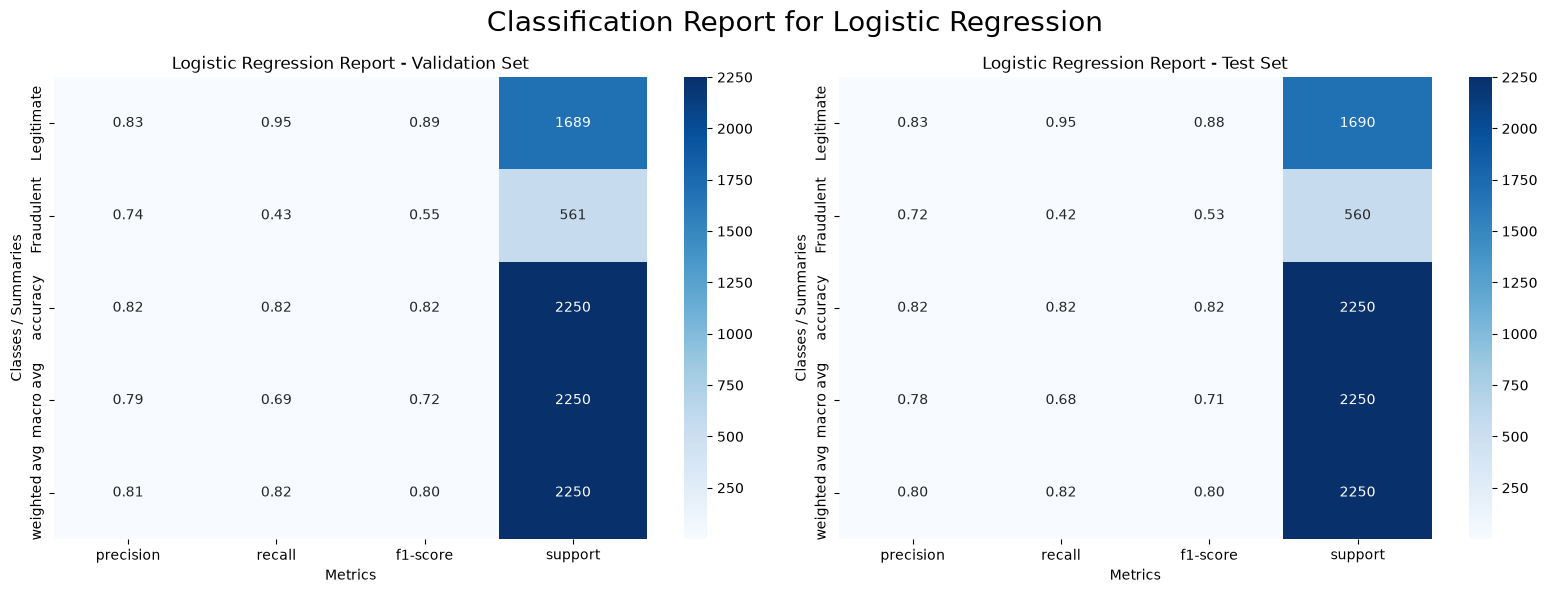

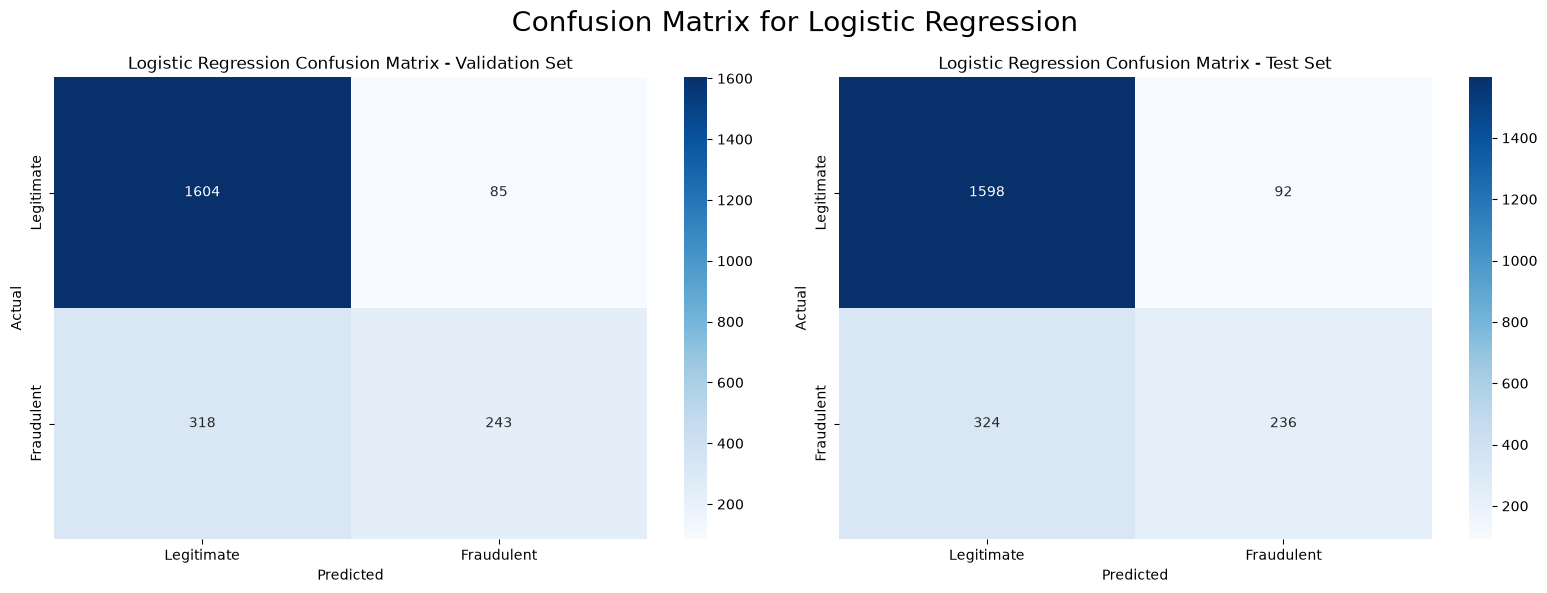

In [36]:
# ----------------- MODEL EVALUATION - Logistic Regression-----------------
# Evaluate model performance on validation and test sets
lr_classification_report_val = classification_report(y_val, lr_y_val_pred, output_dict=True)
lr_classification_report_test = classification_report(y_test, lr_y_test_pred, output_dict=True)

# Visualization of Classification Report for Validation Set & Test Set
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Classification Report for Logistic Regression", fontsize=20)
# Plot Validation Set on the left axis
plot_classification_report(lr_classification_report_val, title="Logistic Regression Report - Validation Set", ax=axes[0])
# Plot Test Set on the right axis (axes[1])
plot_classification_report(lr_classification_report_test, title="Logistic Regression Report - Test Set", ax=axes[1])
plt.tight_layout()
plt.show()

# Confusion Matrix for Validation and Test Sets
lr_confusion_matrix_val = confusion_matrix(y_val, lr_y_val_pred)
lr_confusion_matrix_test = confusion_matrix(y_test, lr_y_test_pred)

# visualization of Confusion Matrix for Validation Set & Test Set
# Create a single figure with side-by-side subplots (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Confusion Matrix for Logistic Regression", fontsize=20)
# Plot Validation Set on the left axis (axes[0])
plot_confusion_matrix(lr_confusion_matrix_val, title="Logistic Regression Confusion Matrix - Validation Set", ax=axes[0])
# Plot Test Set on the right axis (axes[1])
plot_confusion_matrix(lr_confusion_matrix_test, title="Logistic Regression Confusion Matrix - Test Set", ax=axes[1])
plt.tight_layout()
plt.show()


### ROC-AUC Analysis

ROC-AUC Scores for Logistic Regression
Validation ROC-AUC Score: 0.8261
Test ROC-AUC Score:       0.8367


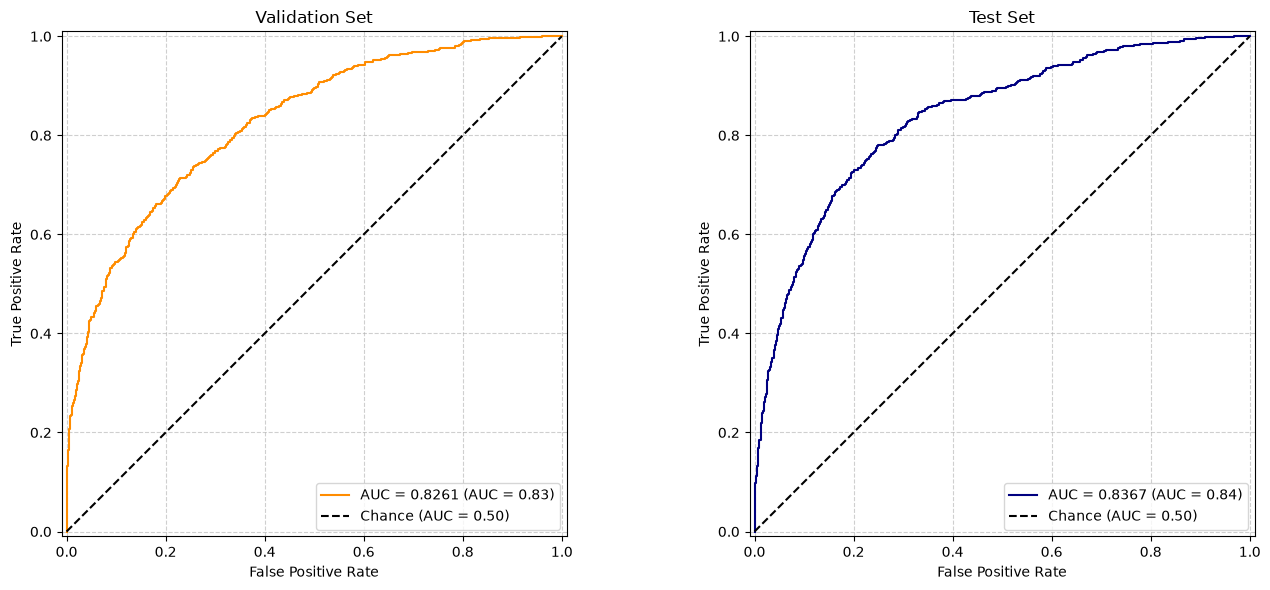

In [37]:
# ----------------- ROC-AUC ANALYSIS -----------------
# Get Predicted probabilities
lr_y_val_proba = lr_model.predict_proba(X_val[features])[:, 1]
lr_y_test_proba = lr_model.predict_proba(X_test[features])[:, 1]

# Calculate ROC-AUC Scores
lr_val_auc = roc_auc_score(y_val, lr_y_val_proba)
lr_test_auc = roc_auc_score(y_test, lr_y_test_proba)

print("ROC-AUC Scores for Logistic Regression")
print(f"Validation ROC-AUC Score: {lr_val_auc:.4f}")
print(f"Test ROC-AUC Score:       {lr_test_auc:.4f}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
lr_val_auc = plot_roc_auc_score(
    y_val, lr_y_val_proba, title="Validation Set", ax=axes[0], color="darkorange"
)
lr_test_auc = plot_roc_auc_score(
    y_test, lr_y_test_proba, title="Test Set", ax=axes[1], color="navy"
)

plt.tight_layout()
plt.show()

## Primary Model - XGBOOST

In [38]:
# XGBoost baseline with class weighting. Fraud recall matters most, so the positive
# class receives more weight before threshold tuning.
negative_count, positive_count = np.bincount(y_train)
base_scale_pos_weight = negative_count / positive_count
print(f"Training class balance -> Legitimate: {negative_count}, Fraudulent: {positive_count}")
print(f"Base scale_pos_weight: {base_scale_pos_weight:.3f}")

xgb_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        n_estimators=300,
        random_state=42,
        objective="binary:logistic",
        eval_metric="aucpr",
        max_depth=4,
        learning_rate=0.05,
        subsample=0.85,
        colsample_bytree=0.85,
        scale_pos_weight=base_scale_pos_weight,
        tree_method="hist",
        n_jobs=1,
    ))
])

# Fit model on training data
xgb_model.fit(X_train, y_train)

# Test and validate model on validation and test data
xgb_y_val_pred = xgb_model.predict(X_val)
xgb_y_test_pred = xgb_model.predict(X_test)

# Create a DataFrame to store predictions and actual values for validation and test sets
xgb_train_pred = pd.DataFrame({
    'Actual': y_train.reset_index(drop=True),
    'Predicted': xgb_model.predict(X_train)
})
xgb_val_pred = pd.DataFrame({
    'Actual': y_val.reset_index(drop=True),
    'Predicted': xgb_y_val_pred
})
xgb_test_pred = pd.DataFrame({
    'Actual': y_test.reset_index(drop=True),
    'Predicted': xgb_y_test_pred
})

# Optionally concatenate with a split column for a single summary table
xgb_results_summary = pd.concat(
    [
        xgb_train_pred.assign(split='train'),
        xgb_val_pred.assign(split='validation'),
        xgb_test_pred.assign(split='test')
    ],
    ignore_index=True
)

print("XGBoost Classifier Model Results Summary (First 20 Rows):")
display(xgb_results_summary.sample(20, random_state=42))


Training class balance -> Legitimate: 7883, Fraudulent: 2617
Base scale_pos_weight: 3.012
XGBoost Classifier Model Results Summary (First 20 Rows):


,Actual,Predicted,split
11499,0,0,validation
6475,0,0,train
13167,0,0,test
862,1,1,train
5970,0,0,train
6706,0,0,train
3017,0,0,train
3781,0,0,train
3898,0,0,train
2250,0,0,train


### Evaluation - XGBoost Classifier

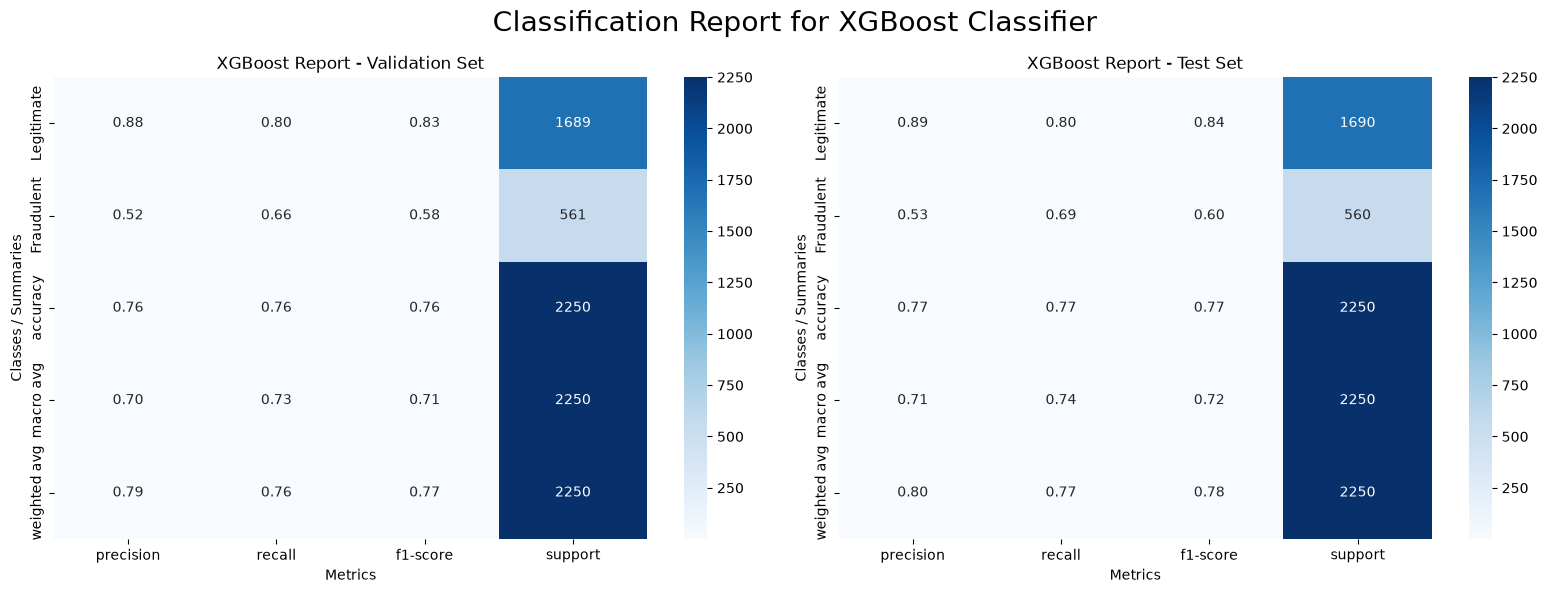

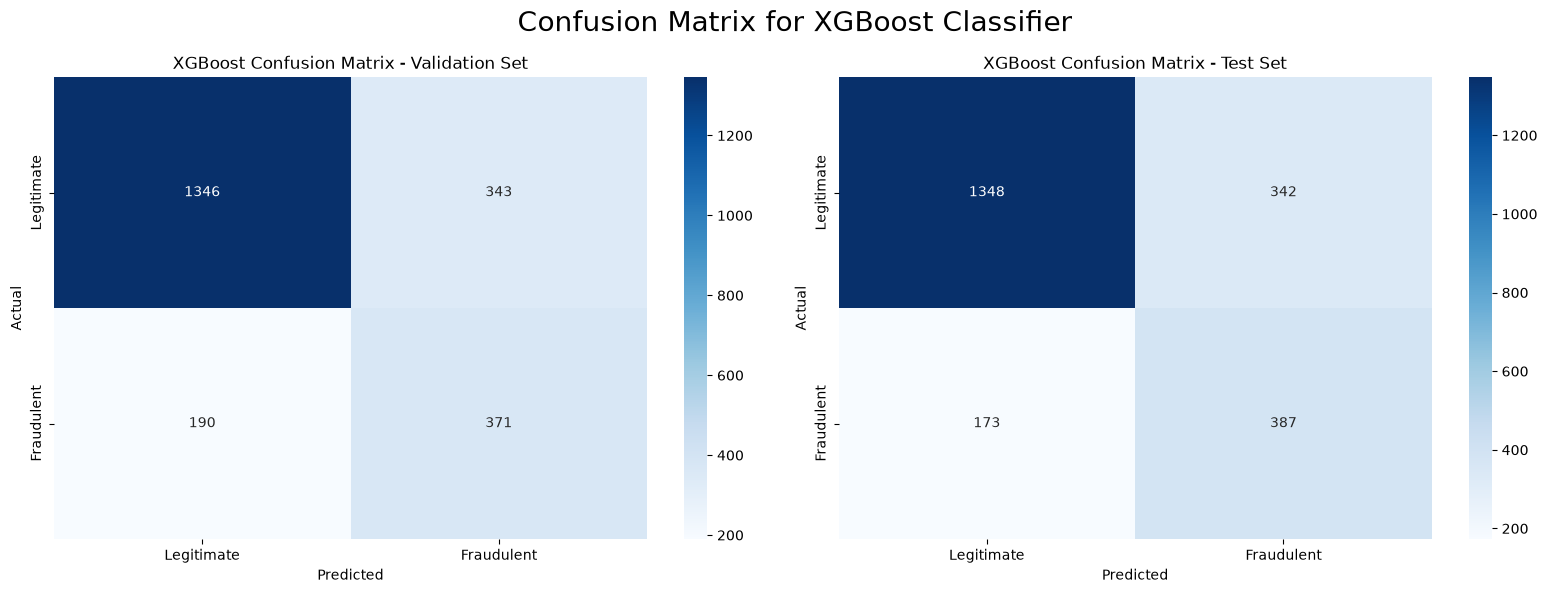

In [39]:
# ----------------- MODEL EVALUATION - XGBoost -----------------
# Evaluate model performance on validation and test sets
xgb_classification_report_val = classification_report(y_val, xgb_y_val_pred, output_dict=True)
xgb_classification_report_test = classification_report(y_test, xgb_y_test_pred, output_dict=True)

# Visualization of Classification Report for Validation Set & Test Set

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Classification Report for XGBoost Classifier", fontsize=20)
# Plot Validation Set on the left axis
plot_classification_report(xgb_classification_report_val, title="XGBoost Report - Validation Set", ax=axes[0])
# Plot Test Set on the right axis (axes[1])
plot_classification_report(xgb_classification_report_test, title="XGBoost Report - Test Set", ax=axes[1])
plt.tight_layout()
plt.show()

# Confusion Matrix for Validation and Test Sets
xgb_confusion_matrix_val = confusion_matrix(y_val, xgb_y_val_pred)
xgb_confusion_matrix_test = confusion_matrix(y_test, xgb_y_test_pred)

# visualization of Confusion Matrix for Validation Set & Test Set
# Create a single figure with side-by-side subplots (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Confusion Matrix for XGBoost Classifier", fontsize=20)
# Plot Validation Set on the left axis (axes[0])
plot_confusion_matrix(xgb_confusion_matrix_val, title="XGBoost Confusion Matrix - Validation Set", ax=axes[0])
# Plot Test Set on the right axis (axes[1])
plot_confusion_matrix(xgb_confusion_matrix_test, title="XGBoost Confusion Matrix - Test Set", ax=axes[1])
plt.tight_layout()
plt.show()


### ROC-AUC Analysis


ROC-AUC Scores for XGBoost Classifier
Validation ROC-AUC Score: 0.8153
Test ROC-AUC Score:       0.8226

PR AUC Scores for XGBOost Classifier
Validation PR AUC Score: 0.2481
Test PR AUC Score: 0.6299


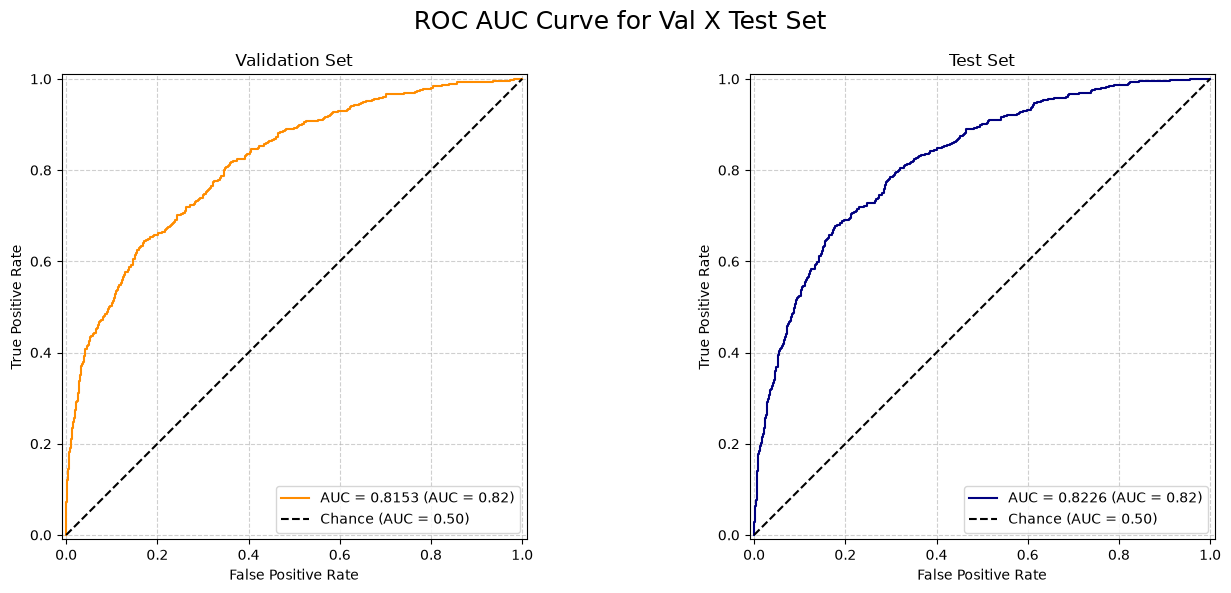

In [60]:
# ----------------- ROC-AUC ANALYSIS -----------------
# Get Predicted probabilities
xgb_y_val_proba = xgb_model.predict_proba(X_val)[:, 1]
xgb_y_test_proba = xgb_model.predict_proba(X_test)[:, 1]

# Calculate ROC-AUC Scores
xgb_val_auc = roc_auc_score(y_val, xgb_y_val_proba)
xgb_test_auc = roc_auc_score(y_test, xgb_y_test_proba)

# Calculate PR AUC
# For Test
xgb_test_precision, xgb_test_recall, _ = precision_recall_curve(y_test, xgb_y_test_proba)
xgb_test_pr_auc = auc(xgb_test_recall, xgb_test_precision)
# For Val
xgb_val_precision, xgb_val_recall, _ = precision_recall_curve(y_test, xgb_y_val_proba)
xgb_val_pr_auc = auc(xgb_val_recall, xgb_val_precision)

print("ROC-AUC Scores for XGBoost Classifier")
print(f"Validation ROC-AUC Score: {xgb_val_auc:.4f}")
print(f"Test ROC-AUC Score:       {xgb_test_auc:.4f}")

print("\nPR AUC Scores for XGBOost Classifier")
print(f"Validation PR AUC Score: {xgb_val_pr_auc:.4f}")
print(f"Test PR AUC Score: {xgb_test_pr_auc:.4f}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
xgb_val_auc = plot_roc_auc_score(
    y_val, xgb_y_val_proba, title="Validation Set", ax=axes[0], color="darkorange"
)
xgb_test_auc = plot_roc_auc_score(
    y_test, xgb_y_test_proba, title="Test Set", ax=axes[1], color="navy"
)

plt.suptitle("ROC AUC Curve for Val X Test Set", fontsize=18)
plt.tight_layout()
plt.show()

## HyperParameter Tuning - XGBoost Classifier

In [42]:
# Recall-first hyperparameter tuning for fraud detection.
# We refit by F-beta (beta=3), which values recall much more than precision while
# still penalizing a model that marks almost everything as fraud.
param_distributions = {
    "classifier__learning_rate": [0.01, 0.03, 0.05, 0.08, 0.1],
    "classifier__n_estimators": [250, 400, 600, 800],
    "classifier__max_depth": [2, 3, 4, 5],
    "classifier__subsample": [0.7, 0.85, 1.0],
    "classifier__colsample_bytree": [0.7, 0.85, 1.0],
    "classifier__min_child_weight": [1, 3, 5, 7],
    "classifier__gamma": [0, 0.1, 0.3, 0.5],
    "classifier__reg_alpha": [0, 0.01, 0.1],
    "classifier__reg_lambda": [1, 3, 5, 10],
    "classifier__scale_pos_weight": [
        base_scale_pos_weight,
        base_scale_pos_weight * 1.5,
        base_scale_pos_weight * 2.0,
        base_scale_pos_weight * 3.0,
    ],
}

recall_first_scoring = {
    "recall": "recall",
    "average_precision": "average_precision",
    "fbeta_3": make_scorer(fbeta_score, beta=3),
}

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_distributions,
    n_iter=25,
    cv=cv_strategy,
    scoring=recall_first_scoring,
    refit="fbeta_3",
    random_state=42,
    n_jobs=-1,
    verbose=1,
    return_train_score=True,
)

# Fit to data. The validation and test sets remain untouched for threshold selection and final reporting.
random_search.fit(X_train, y_train)

# Access results
print(f"Best Parameters: {random_search.best_params_}")
print(f"Best CV F-beta(3) Score: {random_search.best_score_:.4f}")
print(f"Best CV Recall: {random_search.cv_results_['mean_test_recall'][random_search.best_index_]:.4f}")
print(f"Best CV Average Precision: {random_search.cv_results_['mean_test_average_precision'][random_search.best_index_]:.4f}")
print(f"Best Estimator: {random_search.best_estimator_}")

# Fit best model
xgb_best_model = random_search.best_estimator_

# Default 0.5 predictions are retained only as a baseline. Production decisions use the optimized threshold below.
xgb_best_y_val_pred_default = xgb_best_model.predict(X_val)
xgb_best_y_test_pred_default = xgb_best_model.predict(X_test)

# Backward-compatible aliases for earlier plots/cells.
xgb_best_y_val_pred = xgb_best_y_val_pred_default
xgb_best_y_test_pred = xgb_best_y_test_pred_default

# Create a DataFrame to store predictions and actual values for validation and test sets
xgb_best_train_pred = pd.DataFrame({
    'Actual': y_train.reset_index(drop=True),
    'Predicted': xgb_best_model.predict(X_train)
})
xgb_best_val_pred = pd.DataFrame({
    'Actual': y_val.reset_index(drop=True),
    'Predicted': xgb_best_y_val_pred_default
})
xgb_best_test_pred = pd.DataFrame({
    'Actual': y_test.reset_index(drop=True),
    'Predicted': xgb_best_y_test_pred_default
})

# Optionally concatenate with a split column for a single summary table
xgb_best_results_summary = pd.concat(
    [
        xgb_best_train_pred.assign(split='train'),
        xgb_best_val_pred.assign(split='validation'),
        xgb_best_test_pred.assign(split='test')
    ],
    ignore_index=True
)

print("XGBoost Best Model Default-Threshold Results Summary (First 20 Rows):")
display(xgb_best_results_summary.sample(20, random_state=42))


Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best Parameters: {'classifier__subsample': 0.7, 'classifier__scale_pos_weight': np.float64(9.03668322506687), 'classifier__reg_lambda': 10, 'classifier__reg_alpha': 0, 'classifier__n_estimators': 800, 'classifier__min_child_weight': 7, 'classifier__max_depth': 3, 'classifier__learning_rate': 0.01, 'classifier__gamma': 0.5, 'classifier__colsample_bytree': 0.85}
Best CV F-beta(3) Score: 0.7913
Best CV Recall: 0.9350
Best CV Average Precision: 0.6352
Best Estimator: Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('scaler', StandardScaler(),
                                                  ['transaction_amount',
                                                   'order_quantity',
                                                   'customer_age',
                                                   'customer_tenure_months',
                                                   'account_age_days',
  

,Actual,Predicted,split
11499,0,1,validation
6475,0,0,train
13167,0,0,test
862,1,1,train
5970,0,1,train
6706,0,1,train
3017,0,0,train
3781,0,1,train
3898,0,0,train
2250,0,0,train


### Evaluation - Tuned XGBoost

RECALL-FIRST PRODUCTION THRESHOLD (selected on Validation set only)
Minimum required fraud recall: 0.995
Selected threshold          : 0.189626
Validation expected cost    : 8355.0
Validation precision        : 0.2513
Validation recall           : 1.0000
Validation F-beta(3)        : 0.7705
TP / FP / FN / TN           : 561 / 1671 / 0 / 18

VALIDATION - Classification Report @ threshold = 0.189626
              precision    recall  f1-score   support

           0     1.0000    0.0107    0.0211      1689
           1     0.2513    1.0000    0.4017       561

    accuracy                         0.2573      2250
   macro avg     0.6257    0.5053    0.2114      2250
weighted avg     0.8133    0.2573    0.1160      2250

Confusion Matrix:
[[  18 1671]
 [   0  561]]

Business Cost (FP x 5.0 + FN x 100.0) = 8355.0
Fraud Recall     : 1.0000
Fraud Precision  : 0.2513
F-beta(3)        : 0.7705
ROC-AUC          : 0.8196
Average Precision: 0.6599

TEST - Classification Report @ threshold = 0.189

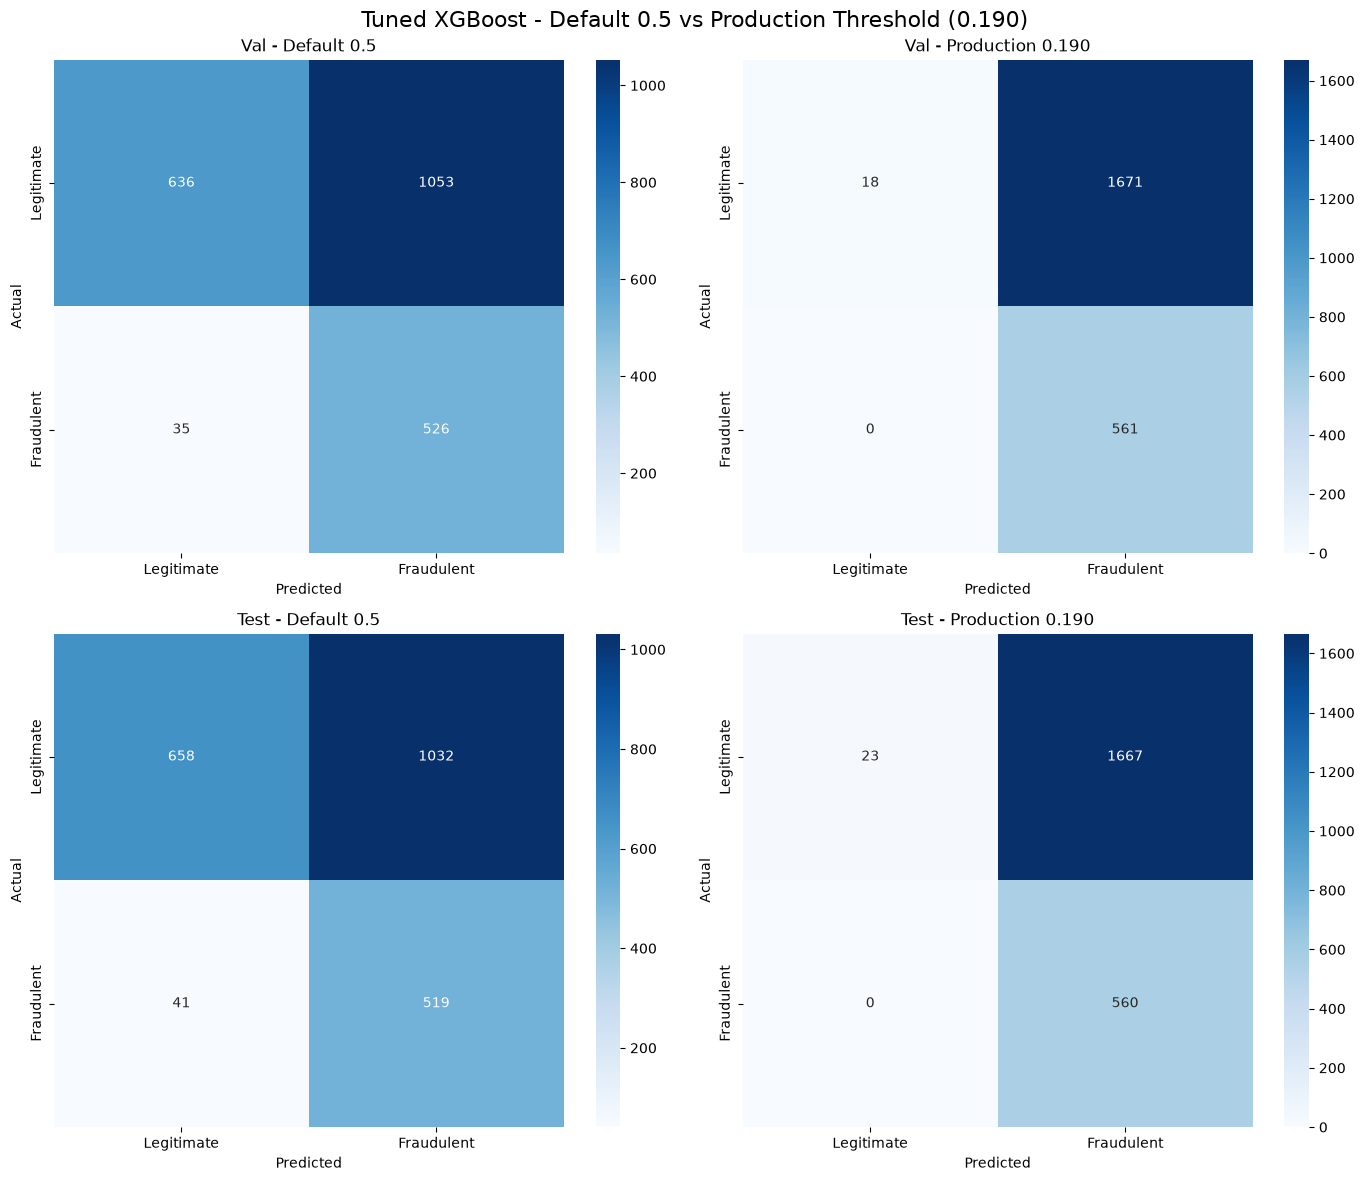

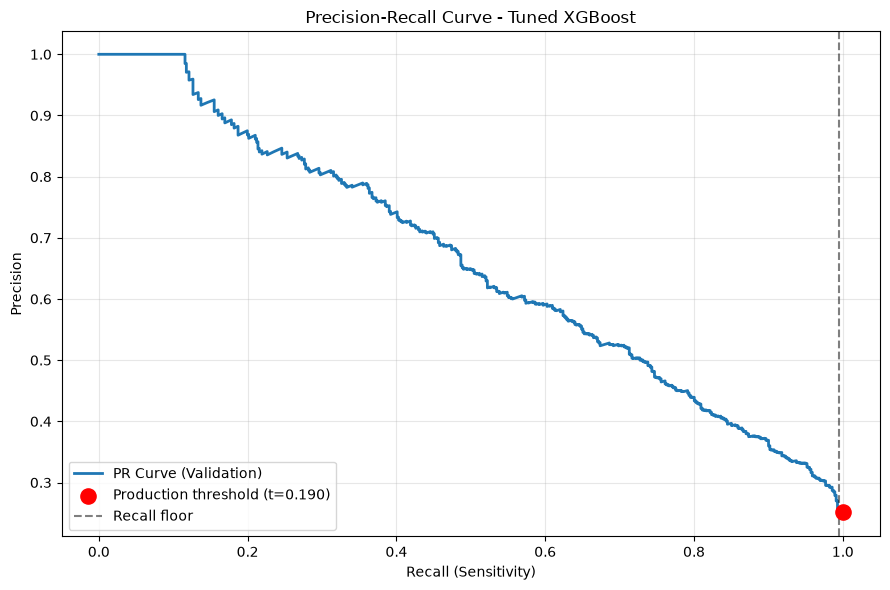


>>> Recommended production threshold to save: 0.189626


In [43]:
# ============================================================
# RECALL-FIRST THRESHOLD OPTIMIZATION + PRODUCTION EVALUATION
# ============================================================

# ---------- 1. Get probability predictions ----------
xgb_best_y_val_proba = xgb_best_model.predict_proba(X_val)[:, 1]
xgb_best_y_test_proba = xgb_best_model.predict_proba(X_test)[:, 1]

# ---------- 2. Business and operating-point requirements ----------
COST_FP = 5.0       # cost of reviewing / blocking a legitimate transaction
COST_FN = 100.0     # average loss when fraud is missed
MIN_FRAUD_RECALL = 0.995


def threshold_metrics_table(y_true, y_proba, cost_fp=COST_FP, cost_fn=COST_FN):
    """Evaluate every available probability threshold without touching the test set."""
    rows = []
    for threshold in np.unique(y_proba):
        y_pred = (y_proba >= threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        precision = tp / (tp + fp) if (tp + fp) else 0.0
        recall = tp / (tp + fn) if (tp + fn) else 0.0
        fbeta_3 = fbeta_score(y_true, y_pred, beta=3, zero_division=0)
        cost = (fp * cost_fp) + (fn * cost_fn)
        rows.append({
            "threshold": float(threshold),
            "precision": precision,
            "recall": recall,
            "fbeta_3": fbeta_3,
            "fp": int(fp),
            "fn": int(fn),
            "tp": int(tp),
            "tn": int(tn),
            "cost": float(cost),
        })
    return pd.DataFrame(rows).sort_values("threshold").reset_index(drop=True)


def select_recall_first_threshold(metrics_df, min_recall=MIN_FRAUD_RECALL):
    """
    Production policy: first satisfy the fraud-recall floor, then choose the lowest-cost
    operating point, with precision as a tie-breaker to reduce analyst load.
    """
    eligible = metrics_df[metrics_df["recall"] >= min_recall].copy()
    if eligible.empty:
        print(
            f"No validation threshold reached recall >= {min_recall:.3f}. "
            "Using the highest-recall threshold available."
        )
        eligible = metrics_df.copy()
        eligible["recall_gap"] = min_recall - eligible["recall"]
        return eligible.sort_values(
            ["recall", "precision", "cost"],
            ascending=[False, False, True],
        ).iloc[0]

    return eligible.sort_values(
        ["cost", "precision", "threshold"],
        ascending=[True, False, False],
    ).iloc[0]


validation_threshold_metrics = threshold_metrics_table(y_val, xgb_best_y_val_proba)
best_metrics = select_recall_first_threshold(validation_threshold_metrics)
best_threshold = float(best_metrics["threshold"])

print("=" * 78)
print("RECALL-FIRST PRODUCTION THRESHOLD (selected on Validation set only)")
print("=" * 78)
print(f"Minimum required fraud recall: {MIN_FRAUD_RECALL:.3f}")
print(f"Selected threshold          : {best_threshold:.6f}")
print(f"Validation expected cost    : {best_metrics['cost']:.1f}")
print(f"Validation precision        : {best_metrics['precision']:.4f}")
print(f"Validation recall           : {best_metrics['recall']:.4f}")
print(f"Validation F-beta(3)        : {best_metrics['fbeta_3']:.4f}")
print(f"TP / FP / FN / TN           : {int(best_metrics['tp'])} / {int(best_metrics['fp'])} / "
      f"{int(best_metrics['fn'])} / {int(best_metrics['tn'])}")
print("=" * 78)

# ---------- 3. Apply the same threshold to both Validation and Test ----------
xgb_best_y_val_pred = (xgb_best_y_val_proba >= best_threshold).astype(int)
xgb_best_y_test_pred = (xgb_best_y_test_proba >= best_threshold).astype(int)

# These aliases make every downstream cell evaluate the production operating point.
# y_val_pred_opt = xgb_best_y_val_pred_opt
# y_test_pred_opt = xgb_best_y_test_pred_opt
# xgb_best_y_val_pred = xgb_best_y_val_pred_opt
# xgb_best_y_test_pred = xgb_best_y_test_pred_opt

# ---------- 4. Full evaluation at the production operating point ----------
def evaluate_at_threshold(y_true, y_pred, y_proba, set_name="Set"):
    print(f"\n{'='*78}")
    print(f"{set_name} - Classification Report @ threshold = {best_threshold:.6f}")
    print(f"{'='*78}")
    print(classification_report(y_true, y_pred, digits=4, zero_division=0))

    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    cost = fp * COST_FP + fn * COST_FN

    print(f"Confusion Matrix:\n{cm}")
    print(f"\nBusiness Cost (FP x {COST_FP} + FN x {COST_FN}) = {cost:.1f}")
    print(f"Fraud Recall     : {recall_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"Fraud Precision  : {precision_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"F-beta(3)        : {fbeta_score(y_true, y_pred, beta=3, zero_division=0):.4f}")
    print(f"ROC-AUC          : {roc_auc_score(y_true, y_proba):.4f}")
    print(f"Average Precision: {average_precision_score(y_true, y_proba):.4f}")

    return cm, cost

cm_val, cost_val = evaluate_at_threshold(y_val, xgb_best_y_val_pred, xgb_best_y_val_proba, "VALIDATION")
cm_test, cost_test = evaluate_at_threshold(y_test, xgb_best_y_test_pred, xgb_best_y_test_proba, "TEST")

# ---------- 5. Side-by-side Confusion Matrices: default 0.5 vs production threshold ----------
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle(f"Tuned XGBoost - Default 0.5 vs Production Threshold ({best_threshold:.3f})", fontsize=16)

plot_confusion_matrix(
    confusion_matrix(y_val, xgb_best_y_val_pred_default),
    "Val - Default 0.5",
    axes[0, 0],
)
plot_confusion_matrix(cm_val, f"Val - Production {best_threshold:.3f}", axes[0, 1])
plot_confusion_matrix(
    confusion_matrix(y_test, xgb_best_y_test_pred_default),
    "Test - Default 0.5",
    axes[1, 0],
)
plot_confusion_matrix(cm_test, f"Test - Production {best_threshold:.3f}", axes[1, 1])

plt.tight_layout()
plt.show()

# ---------- 6. Precision-Recall curve with chosen operating point ----------
precision_curve, recall_curve, pr_thresholds = precision_recall_curve(y_val, xgb_best_y_val_proba)
fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(recall_curve, precision_curve, label="PR Curve (Validation)", linewidth=2)
ax.scatter(
    best_metrics["recall"],
    best_metrics["precision"],
    color="red",
    s=120,
    zorder=5,
    label=f"Production threshold (t={best_threshold:.3f})",
)
ax.axvline(MIN_FRAUD_RECALL, color="black", linestyle="--", alpha=0.5, label="Recall floor")
ax.set_xlabel("Recall (Sensitivity)")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve - Tuned XGBoost")
ax.legend(loc="lower left")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n>>> Recommended production threshold to save: {best_threshold:.6f}")


#### Classification Report - Production Model (XGBoost Tuned)

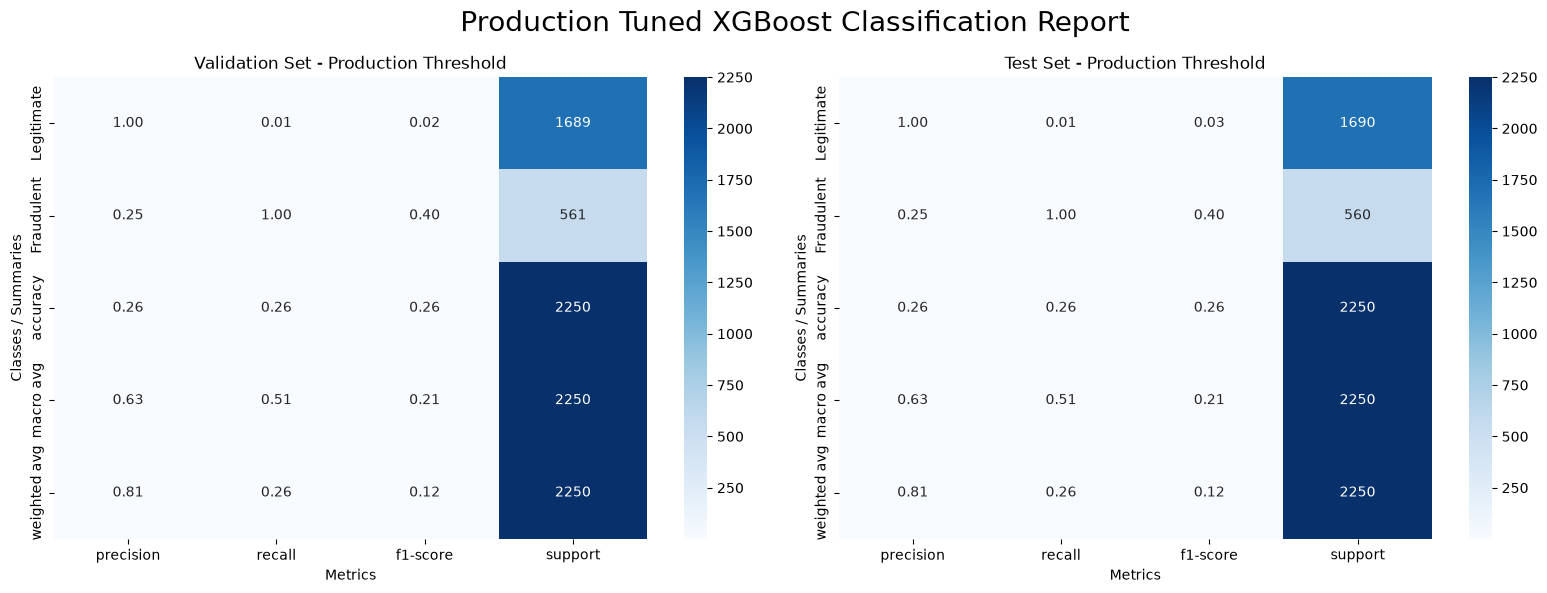

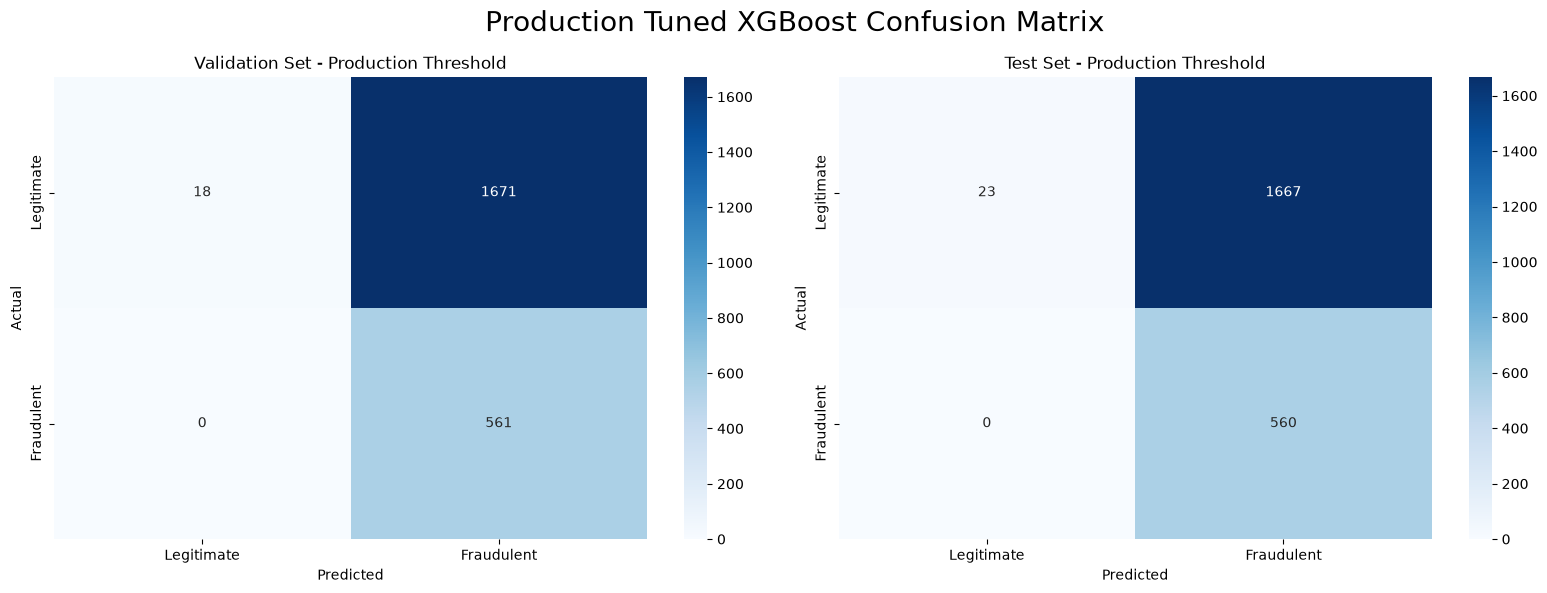

In [44]:
# ----------------- PRODUCTION MODEL ARTIFACT + FINAL REPORT -----------------
# These reports use the optimized threshold selected above, not the default 0.5 cutoff.
xgb_best_classification_report_val = classification_report(
    y_val,
    xgb_best_y_val_pred,
    output_dict=True,
    zero_division=0,
)
xgb_best_classification_report_test = classification_report(
    y_test,
    xgb_best_y_test_pred,
    output_dict=True,
    zero_division=0,
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Production Tuned XGBoost Classification Report", fontsize=20)
plot_classification_report(
    xgb_best_classification_report_val,
    title="Validation Set - Production Threshold",
    ax=axes[0],
)
plot_classification_report(
    xgb_best_classification_report_test,
    title="Test Set - Production Threshold",
    ax=axes[1],
)
plt.tight_layout()
plt.show()

xgb_best_confusion_matrix_val = confusion_matrix(y_val, xgb_best_y_val_pred)
xgb_best_confusion_matrix_test = confusion_matrix(y_test, xgb_best_y_test_pred)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Production Tuned XGBoost Confusion Matrix", fontsize=20)
plot_confusion_matrix(
    xgb_best_confusion_matrix_val,
    title="Validation Set - Production Threshold",
    ax=axes[0],
)
plot_confusion_matrix(
    xgb_best_confusion_matrix_test,
    title="Test Set - Production Threshold",
    ax=axes[1],
)
plt.tight_layout()
plt.show()

production_metrics = {
    "validation": {
        "threshold": best_threshold,
        "recall": recall_score(y_val, xgb_best_y_val_pred, zero_division=0),
        "precision": precision_score(y_val, xgb_best_y_val_pred, zero_division=0),
        "fbeta_3": fbeta_score(y_val, xgb_best_y_val_pred, beta=3, zero_division=0),
        "roc_auc": roc_auc_score(y_val, xgb_best_y_val_proba),
        "average_precision": average_precision_score(y_val, xgb_best_y_val_proba),
        "business_cost": cost_val,
        "confusion_matrix": xgb_best_confusion_matrix_val.tolist(),
    },
    "test": {
        "threshold": best_threshold,
        "recall": recall_score(y_test, xgb_best_y_test_pred, zero_division=0),
        "precision": precision_score(y_test, xgb_best_y_test_pred, zero_division=0),
        "fbeta_3": fbeta_score(y_test, xgb_best_y_test_pred, beta=3, zero_division=0),
        "roc_auc": roc_auc_score(y_test, xgb_best_y_test_proba),
        "average_precision": average_precision_score(y_test, xgb_best_y_test_proba),
        "business_cost": cost_test,
        "confusion_matrix": xgb_best_confusion_matrix_test.tolist(),
    },
}

### Feature Importance

,Features,Importance
0,scaler__ip_x_velocity,0.060801
1,bin__shipping_billing_mismatch,0.051033
2,scaler__transaction_amount,0.049517
3,scaler__login_anomalies,0.046669
4,scaler__log_transaction_amount,0.045091
5,bin__vpn_proxy_used,0.044526
6,bin__new_device,0.040321
7,scaler__failed_payment_rate,0.036800
8,scaler__failed_payment_attempts,0.033844
9,bin__high_risk_country,0.031087


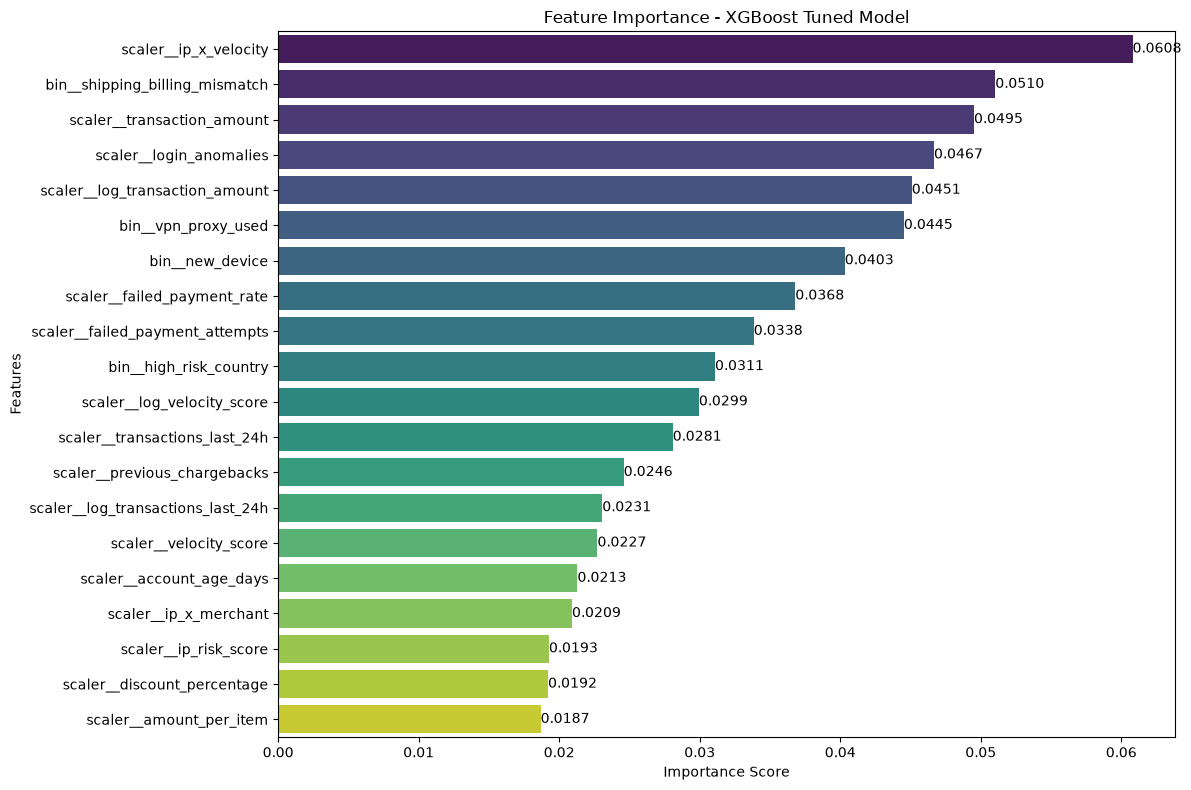

In [58]:
# Feature Importance For Production Model - XGBoost Tuned Model
feature_importance = pd.DataFrame({
    "Features": preprocessor.get_feature_names_out(),
    "Importance": xgb_best_model.named_steps["classifier"].feature_importances_
})

display(feature_importance.sort_values(by="Importance", ascending=False).reset_index(drop=True).head(20))

# Visualize Feature Importance
plt.figure(figsize=(12, 8))
sns.barplot(x="Importance", y="Features", data=feature_importance.sort_values(by="Importance", ascending=False).head(20), hue="Features", palette="viridis", dodge=False, legend=False)
plt.title("Feature Importance - XGBoost Tuned Model")
for container in plt.gca().containers:
    plt.bar_label(container, fmt="%.4f", label_type="edge", fontsize=10)
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

# Save Files

In [45]:
def make_json_safe(value):
    if isinstance(value, dict):
        return {str(k): make_json_safe(v) for k, v in value.items()}
    if isinstance(value, list):
        return [make_json_safe(v) for v in value]
    if isinstance(value, tuple):
        return [make_json_safe(v) for v in value]
    if isinstance(value, np.integer):
        return int(value)
    if isinstance(value, np.floating):
        return float(value)
    if isinstance(value, np.ndarray):
        return value.tolist()
    return value

production_bundle = {
    "model": xgb_best_model,
    "threshold": best_threshold,
    "y_test_pred": xgb_best_y_test_pred,
    "y_val_pred": xgb_best_y_val_pred, 
    "features": features,
    "numerical_features": numerical_features,
    "categorical_features": categorical_features,
    "binary_features": binary_features,
    "target_mapping": {"Legitimate": 0, "Fraudulent": 1},
    "positive_class": "Fraudulent",
    "minimum_fraud_recall": MIN_FRAUD_RECALL,
    "cost_false_positive": COST_FP,
    "cost_false_negative": COST_FN,
    "best_params": random_search.best_params_,
    "cv_best_fbeta_3": float(random_search.best_score_),
    "metrics": production_metrics,
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
}

MODELS_DIR = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
model_artifact_path = MODELS_DIR / "xgb_fraud_recall_optimized.joblib"
metadata_path = MODELS_DIR / "xgb_fraud_recall_optimized_metadata.json"

joblib.dump(production_bundle, model_artifact_path)
metadata_to_save = make_json_safe({k: v for k, v in production_bundle.items() if k != "model"})
metadata_path.write_text(json.dumps(metadata_to_save, indent=2), encoding="utf-8")

print("Production artifact saved:", model_artifact_path)
print("Production metadata saved:", metadata_path)
print("\nProduction metrics summary:")
display(pd.DataFrame(production_metrics).T)

# Example production inference:
# bundle = joblib.load(model_artifact_path)
# fraud_probability = bundle["model"].predict_proba(new_transactions[bundle["features"]])[:, 1]
# fraud_flag = (fraud_probability >= bundle["threshold"]).astype(int)


Production artifact saved: c:\Users\USER\Documents\projects\fraud detection\models\xgb_fraud_recall_optimized.joblib
Production metadata saved: c:\Users\USER\Documents\projects\fraud detection\models\xgb_fraud_recall_optimized_metadata.json

Production metrics summary:


,threshold,recall,precision,fbeta_3,roc_auc,average_precision,business_cost,confusion_matrix
validation,0.189626,1.0,0.251344,0.770499,0.819602,0.659919,8355.0,"[[18, 1671], [0, 561]]"
test,0.189626,1.0,0.251459,0.770607,0.817763,0.620715,8335.0,"[[23, 1667], [0, 560]]"


# Inference Test

Use the saved production bundle to score a small sample of held-out test transactions. The model returns a fraud probability, applies the saved production threshold, and compares each prediction with the actual label.


In [46]:
# ----------------- INFERENCE TEST -----------------
# This simulates production inference on held-out test rows and compares predictions with actual labels.
production_bundle_path = PROJECT_ROOT / "models" / "xgb_fraud_recall_optimized.joblib"
production_bundle = joblib.load(production_bundle_path)

production_model = production_bundle["model"]
production_threshold = production_bundle["threshold"]
production_features = production_bundle["features"]

# Build a small, interpretable sample with both actual fraud and legitimate transactions when available.
inference_sample_size_per_class = 5
fraud_indices = y_test[y_test == 1].sample(
    n=min(inference_sample_size_per_class, int((y_test == 1).sum())),
    random_state=42,
).index
legitimate_indices = y_test[y_test == 0].sample(
    n=min(inference_sample_size_per_class, int((y_test == 0).sum())),
    random_state=42,
).index
sample_indices = fraud_indices.union(legitimate_indices)

X_inference_sample = X_test.loc[sample_indices, production_features].copy()
y_inference_actual = y_test.loc[sample_indices].copy()

fraud_probabilities = production_model.predict_proba(X_inference_sample)[:, 1]
y_inference_pred = (fraud_probabilities >= production_threshold).astype(int)

inference_results = X_inference_sample.copy()
inference_results.insert(0, "transaction_id", df.loc[sample_indices, "transaction_id"].values)
inference_results.insert(1, "actual_label", y_inference_actual.map({0: "Legitimate", 1: "Fraudulent"}).values)
inference_results.insert(2, "predicted_label", pd.Series(y_inference_pred).map({0: "Legitimate", 1: "Fraudulent"}).values)
inference_results.insert(3, "fraud_probability", fraud_probabilities)
inference_results.insert(4, "production_threshold", production_threshold)
inference_results.insert(5, "correct_prediction", y_inference_actual.to_numpy() == y_inference_pred)

print(f"Loaded production bundle: {production_bundle_path}")
print(f"Production threshold: {production_threshold:.6f}")
print("\nInference sample prediction comparison:")
display(
    inference_results[
        [
            "transaction_id",
            "actual_label",
            "predicted_label",
            "fraud_probability",
            "production_threshold",
            "correct_prediction",
            "transaction_amount",
            "ip_risk_score",
            "velocity_score",
            "merchant_risk_score",
            "previous_chargebacks",
            "failed_payment_attempts",
            "login_anomalies",
            "shipping_billing_mismatch",
            "high_risk_country",
            "new_device",
            "vpn_proxy_used",
        ]
    ].sort_values("fraud_probability", ascending=False)
)

sample_cm = confusion_matrix(y_inference_actual, y_inference_pred)
sample_accuracy = (y_inference_actual.to_numpy() == y_inference_pred).mean()
sample_recall = recall_score(y_inference_actual, y_inference_pred, zero_division=0)
sample_precision = precision_score(y_inference_actual, y_inference_pred, zero_division=0)

print("\nInference sample confusion matrix:")
print(sample_cm)
print(f"Sample accuracy : {sample_accuracy:.4f}")
print(f"Sample recall   : {sample_recall:.4f}")
print(f"Sample precision: {sample_precision:.4f}")
print("\nInference sample classification report:")
print(classification_report(y_inference_actual, y_inference_pred, target_names=["Legitimate", "Fraudulent"], digits=4, zero_division=0))


Loaded production bundle: c:\Users\USER\Documents\projects\fraud detection\models\xgb_fraud_recall_optimized.joblib
Production threshold: 0.189626

Inference sample prediction comparison:


,transaction_id,actual_label,predicted_label,fraud_probability,production_threshold,correct_prediction,transaction_amount,ip_risk_score,velocity_score,merchant_risk_score,previous_chargebacks,failed_payment_attempts,login_anomalies,shipping_billing_mismatch,high_risk_country,new_device,vpn_proxy_used
6274,TXN00006275,Fraudulent,Fraudulent,0.939358,0.189626,True,128.47,23.39,40.07,42.76,1,0,1,1,0,0,0
1994,TXN00001995,Fraudulent,Fraudulent,0.928095,0.189626,True,22.66,10.32,67.77,10.15,0,0,1,1,0,1,1
4967,TXN00004968,Legitimate,Fraudulent,0.885238,0.189626,False,115.65,34.18,43.16,37.42,0,1,0,0,1,1,0
12033,TXN00012034,Fraudulent,Fraudulent,0.834879,0.189626,True,64.47,65.04,12.03,39.32,0,0,0,0,0,1,0
8767,TXN00008768,Legitimate,Fraudulent,0.757833,0.189626,False,62.05,27.90,39.09,41.47,0,0,0,0,0,1,0
7568,TXN00007569,Fraudulent,Fraudulent,0.723358,0.189626,True,52.72,23.40,45.77,50.53,0,1,0,0,0,0,0
11209,TXN00011210,Legitimate,Fraudulent,0.538422,0.189626,False,7.97,21.74,9.73,9.50,0,1,2,0,0,0,0
12509,TXN00012510,Fraudulent,Fraudulent,0.524495,0.189626,True,50.80,25.31,15.52,45.15,0,1,0,0,0,0,0
13874,TXN00013875,Legitimate,Fraudulent,0.390511,0.189626,False,10.92,15.73,13.38,36.47,0,1,1,0,0,0,0
6641,TXN00006642,Legitimate,Fraudulent,0.353837,0.189626,False,28.78,35.75,3.92,53.43,0,0,0,0,0,0,0



Inference sample confusion matrix:
[[0 5]
 [0 5]]
Sample accuracy : 0.5000
Sample recall   : 1.0000
Sample precision: 0.5000

Inference sample classification report:
              precision    recall  f1-score   support

  Legitimate     0.0000    0.0000    0.0000         5
  Fraudulent     0.5000    1.0000    0.6667         5

    accuracy                         0.5000        10
   macro avg     0.2500    0.5000    0.3333        10
weighted avg     0.2500    0.5000    0.3333        10

